#**COMP1886 Machine Learning - Coursework | ID: 001260070**

**Task 2: Exploratory Data Analysis (EDA)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

In [2]:
employees = pd.read_excel('Employees (Industry).xlsx')
mean_pay = pd.read_excel('Mean Pay (Industry).xlsx')

Inspection of Datasets:

In [3]:
employees.describe()

,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,Information and communication,...,Real estate,"Professional, scientific and technical",Administrative and support services,Public administration and defence; social security,Education,Health and social work,"Arts, entertainment and recreation",Other service activities,Households and Extraterritorial,UK
count,133.000000,133.000000,1.330000e+02,133.000000,133.000000,1.330000e+02,1.330000e+02,1.330000e+02,1.330000e+02,1.330000e+02,...,133.000000,1.330000e+02,1.330000e+02,1.330000e+02,1.330000e+02,1.330000e+02,133.000000,133.000000,133.000000,1.330000e+02
mean,186533.744361,50264.060150,2.376253e+06,102654.639098,180408.714286,1.247829e+06,4.405825e+06,1.310838e+06,2.006529e+06,1.200783e+06,...,428510.571429,2.173404e+06,2.446090e+06,1.468484e+06,3.067060e+06,3.901818e+06,580328.293233,526694.654135,108772.428571,2.884919e+07
std,12652.162475,3078.282647,4.252646e+04,5874.828231,15550.709671,7.181218e+04,7.937458e+04,6.354170e+04,1.441577e+05,7.792765e+04,...,21308.402833,1.843312e+05,6.893114e+04,4.881886e+04,9.879727e+04,3.122798e+05,40682.351925,17289.732064,6116.420871,1.034902e+06
min,163087.000000,47496.000000,2.275847e+06,91377.000000,153640.000000,1.056589e+06,4.266394e+06,1.163634e+06,1.677264e+06,1.057055e+06,...,393745.000000,1.863203e+06,2.289652e+06,1.402209e+06,2.901803e+06,3.419006e+06,467808.000000,490853.000000,93648.000000,2.686540e+07
25%,175972.000000,48503.000000,2.342156e+06,99045.000000,167995.000000,1.206048e+06,4.340297e+06,1.268188e+06,1.916374e+06,1.138364e+06,...,411232.000000,2.004784e+06,2.397191e+06,1.418386e+06,3.000890e+06,3.643792e+06,555285.000000,515340.000000,106937.000000,2.808811e+07
50%,186112.000000,49259.000000,2.372508e+06,102492.000000,180004.000000,1.246917e+06,4.402483e+06,1.326883e+06,2.016805e+06,1.196040e+06,...,424213.000000,2.137751e+06,2.448475e+06,1.472546e+06,3.032572e+06,3.851416e+06,587211.000000,527255.000000,111004.000000,2.874946e+07
75%,196912.000000,50201.000000,2.410921e+06,104758.000000,194017.000000,1.314197e+06,4.466132e+06,1.359405e+06,2.128095e+06,1.268559e+06,...,444800.000000,2.380387e+06,2.498185e+06,1.504714e+06,3.137082e+06,4.121130e+06,607361.000000,538094.000000,113153.000000,2.982903e+07
max,208610.000000,60157.000000,2.454452e+06,115849.000000,209723.000000,1.352742e+06,4.591535e+06,1.402395e+06,2.255164e+06,1.329113e+06,...,470512.000000,2.464002e+06,2.593681e+06,1.572076e+06,3.275067e+06,4.465093e+06,652174.000000,559789.000000,115494.000000,3.059833e+07


In [4]:
mean_pay.describe()

,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,Information and communication,...,Real estate,"Professional, scientific and technical",Administrative and support services,Public administration and defence; social security,Education,Health and social work,"Arts, entertainment and recreation",Other service activities,Households and Extraterritorial,UK
count,129.000000,131.000000,130.000000,130.000000,128.000000,132.000000,132.000000,132.000000,129.000000,127.000000,...,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,131.000000,131.000000,132.000000
mean,1868.341085,5685.045802,2925.000000,4287.530769,2864.734375,2726.621212,1992.196970,2747.227273,1326.736434,4298.488189,...,2644.204545,3647.651515,2248.863636,2744.613636,2264.000000,2310.515152,2199.719697,1870.251908,1325.748092,2627.931818
std,306.186358,772.983101,344.965025,697.381505,334.815626,260.142402,291.959148,306.047334,180.405988,746.556347,...,318.045048,646.084377,398.877466,318.521241,267.521933,327.908279,297.765478,256.428018,177.432082,377.117456
min,0.000000,4745.000000,2463.000000,3364.000000,2381.000000,2310.000000,1602.000000,2393.000000,1086.000000,3270.000000,...,2130.000000,2799.000000,1742.000000,2360.000000,1940.000000,1932.000000,1728.000000,1521.000000,1084.000000,2133.000000
25%,1653.000000,5116.500000,2664.000000,3787.000000,2581.750000,2532.750000,1760.750000,2505.750000,1183.000000,3607.500000,...,2390.250000,3107.000000,1918.000000,2472.500000,2027.000000,2021.750000,1955.500000,1659.500000,1173.500000,2308.750000
50%,1834.000000,5454.000000,2817.500000,4115.500000,2776.000000,2655.000000,1893.500000,2632.000000,1270.000000,4119.000000,...,2598.000000,3426.500000,2109.500000,2671.000000,2203.000000,2205.000000,2125.000000,1774.000000,1269.000000,2516.000000
75%,2071.000000,5978.000000,3131.000000,4765.750000,3080.000000,2927.500000,2191.500000,2920.000000,1447.000000,4941.000000,...,2887.000000,4174.000000,2566.250000,2991.500000,2420.250000,2544.750000,2443.500000,2048.000000,1460.000000,2917.250000
max,2429.000000,8322.000000,4024.000000,6576.000000,3810.000000,3407.000000,2949.000000,3526.000000,1755.000000,6338.000000,...,3583.000000,5634.000000,3366.000000,3612.000000,2941.000000,3200.000000,2894.000000,2503.000000,1695.000000,3739.000000


In [5]:
employees.head()

,Date,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,...,Real estate,"Professional, scientific and technical",Administrative and support services,Public administration and defence; social security,Education,Health and social work,"Arts, entertainment and recreation",Other service activities,Households and Extraterritorial,UK
0,July 2014,195597,59358,2337672,92821,155087,1079928,4283572,1166829,1787337,...,394011,1863203,2321467,1521915,2975889,3419006,528033,491769,93648,26893849
1,August 2014,194663,59607,2342156,92678,155203,1092236,4290019,1163634,1801181,...,395070,1863740,2316466,1510945,2901803,3433116,539577,490853,93999,26865396
2,September 2014,190243,59905,2363800,92225,155268,1099190,4298133,1171355,1790801,...,396368,1877156,2346129,1507823,2903446,3435981,539594,495431,94551,26945380
3,October 2014,179615,60040,2362404,92133,155048,1102251,4303220,1171241,1764657,...,395060,1885817,2366977,1504714,2939361,3435950,532466,498201,94340,26965178
4,November 2014,170266,60157,2372508,92448,155276,1109811,4379388,1178976,1768185,...,395324,1899994,2389944,1508328,2980481,3448671,528441,500421,94692,27159526


In [6]:
mean_pay.head()

,Date,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,...,Administrative and support services,Public administration and defence; social security,Education,Health and social work,"Arts, entertainment and recreation",Other service activities,Households and Extraterritorial,UK,Was there any payroll error or Data Issue this month,"Majority of the payroll were contributed by people from region North East, North West or East Midlands"
0,July 2014,0.0,4969.0,2531.0,3584.0,2543.0,2392,1627,2450,1086.0,...,1756,2409,1956,1932,1820,1545.0,1113.0,2151,yes,North East
1,August 2014,1581.0,4793.0,2463.0,3455.0,2381.0,2373,1614,2415,1097.0,...,1742,2371,1978,1937,1806,1557.0,1148.0,2141,no,North East
2,September 2014,1595.0,4866.0,2470.0,3364.0,2394.0,2399,1602,2395,1089.0,...,1752,2377,1973,1943,1788,1521.0,1093.0,2134,yes,North West
3,October 2014,1566.0,4892.0,2477.0,3399.0,2400.0,2398,1633,2407,1103.0,...,1788,2372,1976,1941,1728,1531.0,1084.0,2133,no,East Midlands
4,November 2014,1549.0,4979.0,NaN,3462.0,2426.0,2436,1627,2440,1119.0,...,1774,2360,1974,1948,1777,1566.0,1097.0,2159,no,North East


In [7]:
employees.tail()

,Date,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,...,Real estate,"Professional, scientific and technical",Administrative and support services,Public administration and defence; social security,Education,Health and social work,"Arts, entertainment and recreation",Other service activities,Households and Extraterritorial,UK
128,March 2025,182859,48685,2320269,115025,206077,1330497,4268600,1382043,2072140,...,467468,2443963,2435026,1549725,3263067,4455062,629813,550254,110441,30224726
129,April 2025,186997,48255,2315250,115592,206265,1337024,4272659,1385228,2128095,...,467945,2432698,2408388,1552019,3255485,4450936,641254,552019,109149,30245339
130,May 2025,194591,48207,2316900,115666,208067,1335481,4272675,1388167,2129862,...,468900,2436116,2434225,1559805,3250613,4456378,643980,552372,108459,30302670
131,June 2025,204618,48154,2318758,115849,209390,1335400,4275722,1392795,2133245,...,470512,2437102,2452051,1566187,3265043,4465093,641414,552392,108193,30382663
132,July 2025,208370,47822,2311620,115565,209723,1330123,4267988,1389861,2143479,...,469765,2429595,2486322,1572076,3275067,4461027,649281,550256,109175,30419062


In [8]:
mean_pay.tail()

,Date,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,...,Administrative and support services,Public administration and defence; social security,Education,Health and social work,"Arts, entertainment and recreation",Other service activities,Households and Extraterritorial,UK,Was there any payroll error or Data Issue this month,"Majority of the payroll were contributed by people from region North East, North West or East Midlands"
127,February 2025,2297.0,7223.0,3596.0,5616.0,NaN,3211,2496,3333,NaN,...,3140,3331,2758,2917,2685,2345.0,1632.0,3510,no,East Midlands
128,March 2025,2429.0,8322.0,4024.0,6576.0,3570.0,3407,2949,3526,1738.0,...,3366,3338,2765,2930,2765,2503.0,1665.0,3739,yes,North East
129,April 2025,2424.0,7660.0,3667.0,6027.0,3511.0,3237,2569,3376,1718.0,...,2971,3350,2782,2943,2673,2387.0,1684.0,3287,no,North East
130,May 2025,2429.0,6041.0,3584.0,5524.0,3601.0,3224,2562,3381,1755.0,...,2898,3374,2783,2926,2655,2393.0,1695.0,3280,no,North East
131,June 2025,2414.0,6020.0,3602.0,5821.0,3810.0,3246,2537,3386,1731.0,...,2896,3369,2784,2938,2894,2406.0,1693.0,3291,yes,North West


In [9]:
employees.shape, mean_pay.shape

((133, 22), (132, 24))

Numeric & Categorial Features

In [10]:
numeric_features1 = employees.select_dtypes(include=[np.number])

numeric_features1.columns

Index(['Agriculture, forestry and fishing', 'Mining and quarrying',
       'Manufacturing', 'Energy production and supply',
       'Water supply, sewerage and waste', 'Construction',
       'Wholesale and retail; repair of motor vehicles',
       'Transportation and storage',
       'Accommodation and food service activities',
       'Information and communication', 'Finance and insurance', 'Real estate',
       'Professional, scientific and technical',
       'Administrative and support services',
       'Public administration and defence; social security', 'Education',
       'Health and social work', 'Arts, entertainment and recreation',
       'Other service activities', 'Households and Extraterritorial', 'UK'],
      dtype='object')

In [11]:
type(numeric_features1)

pandas.core.frame.DataFrame

In [12]:
categorical_features1 = employees.select_dtypes(include=[object])

categorical_features1.columns

Index(['Date'], dtype='object')

In [13]:
numeric_features2 = mean_pay.select_dtypes(include=[np.number])

numeric_features2.columns

Index(['Agriculture, forestry and fishing', 'Mining and quarrying',
       'Manufacturing', 'Energy production and supply',
       'Water supply, sewerage and waste', 'Construction',
       'Wholesale and retail; repair of motor vehicles',
       'Transportation and storage',
       'Accommodation and food service activities',
       'Information and communication', 'Finance and insurance', 'Real estate',
       'Professional, scientific and technical',
       'Administrative and support services',
       'Public administration and defence; social security', 'Education',
       'Health and social work', 'Arts, entertainment and recreation',
       'Other service activities', 'Households and Extraterritorial', 'UK'],
      dtype='object')

In [14]:
type(numeric_features2)

pandas.core.frame.DataFrame

In [15]:
categorical_features2 = mean_pay.select_dtypes(include=[object])

categorical_features2.columns

Index(['Date', 'Was there any payroll error or Data Issue this month',
       'Majority of the payroll were contributed by people from region North East, North West or East Midlands'],
      dtype='object')

Missing values & data quality checks

<Axes: >

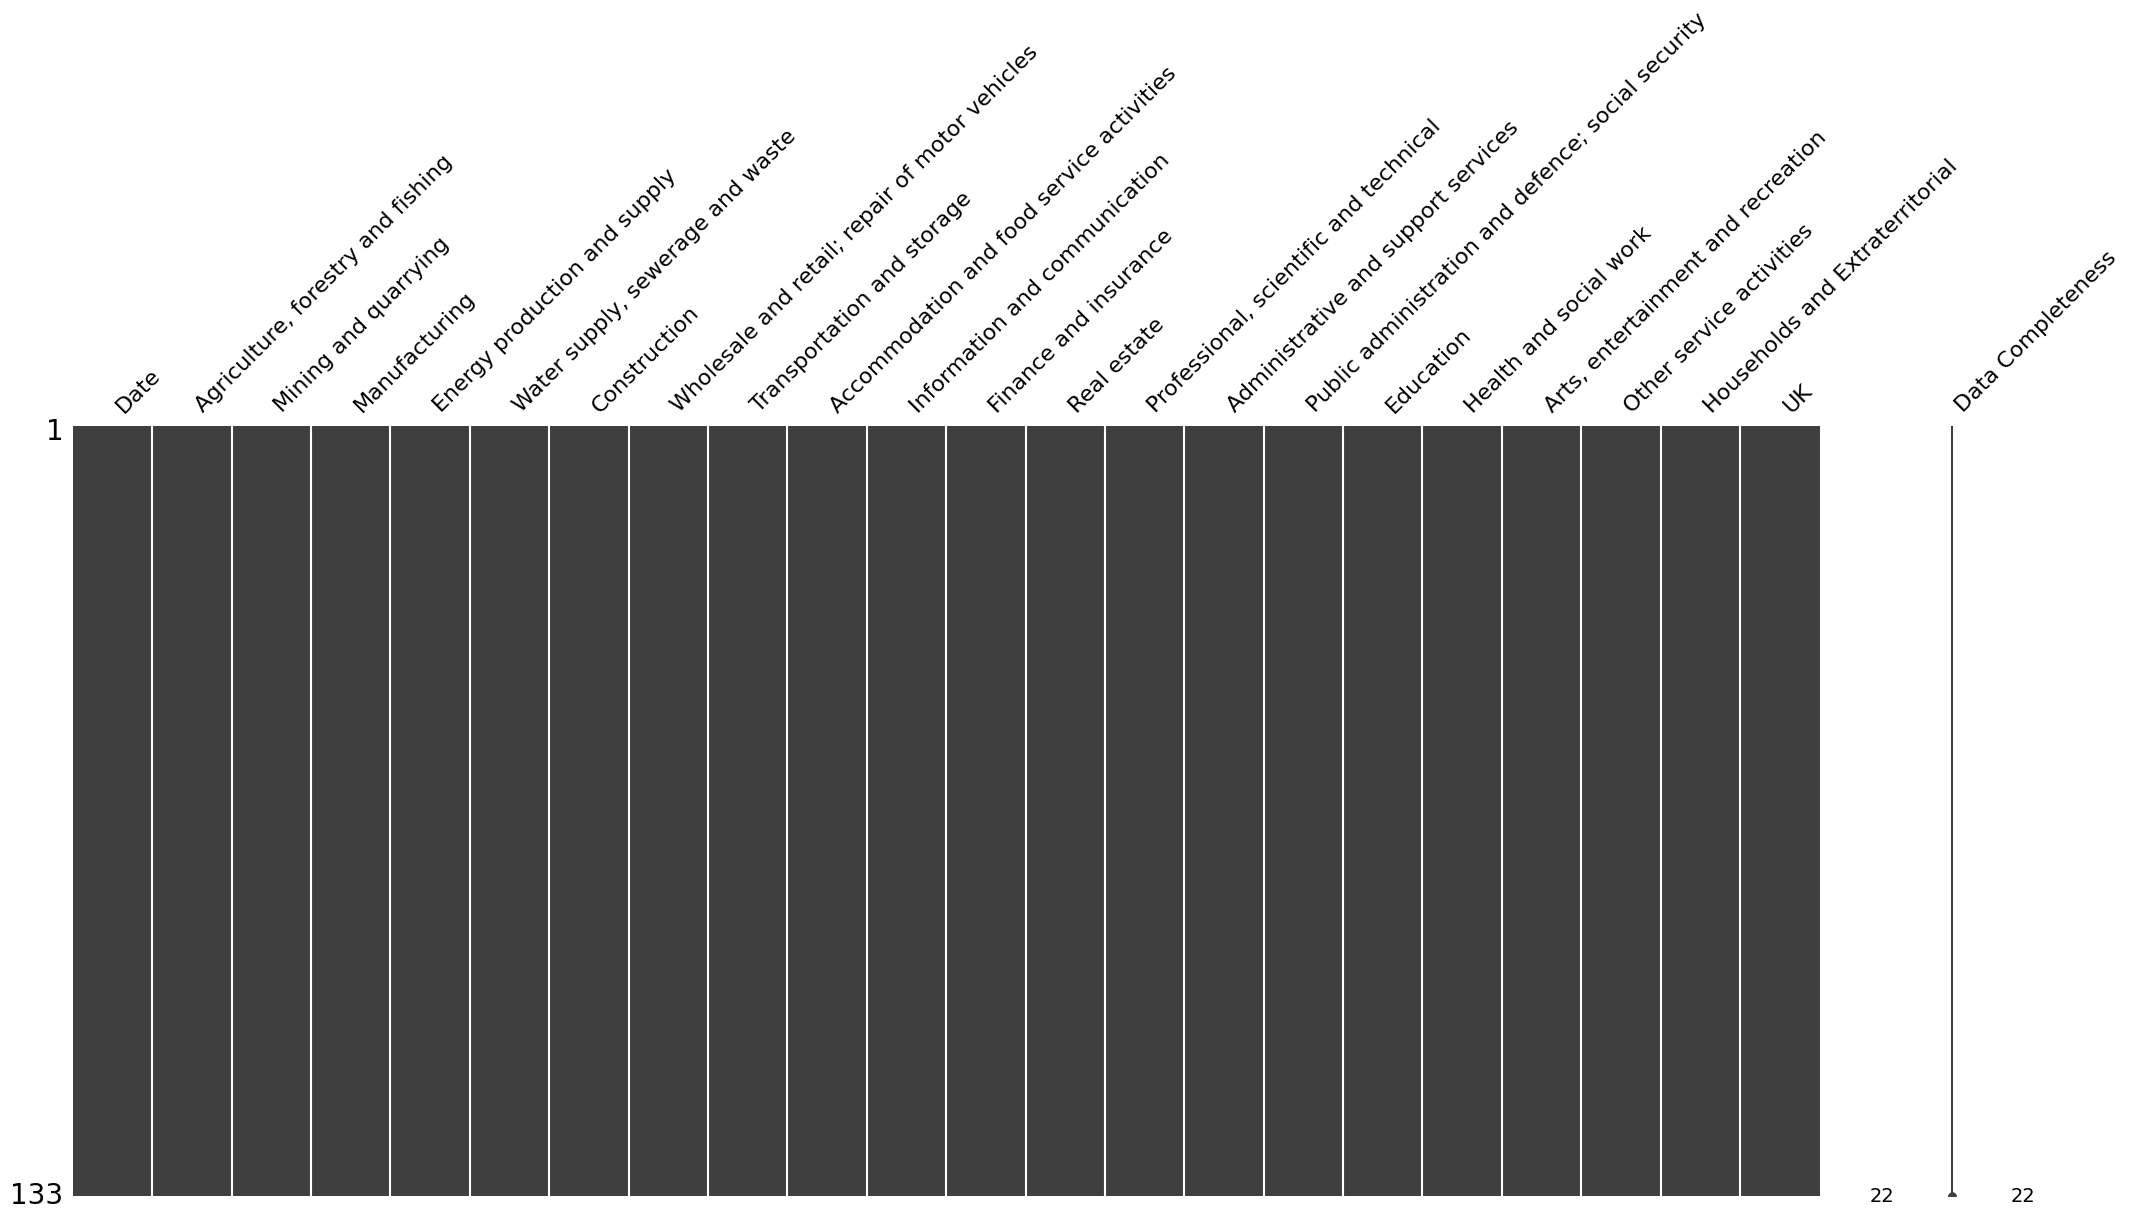

In [16]:
msno.matrix(employees,labels=True)

<Axes: >

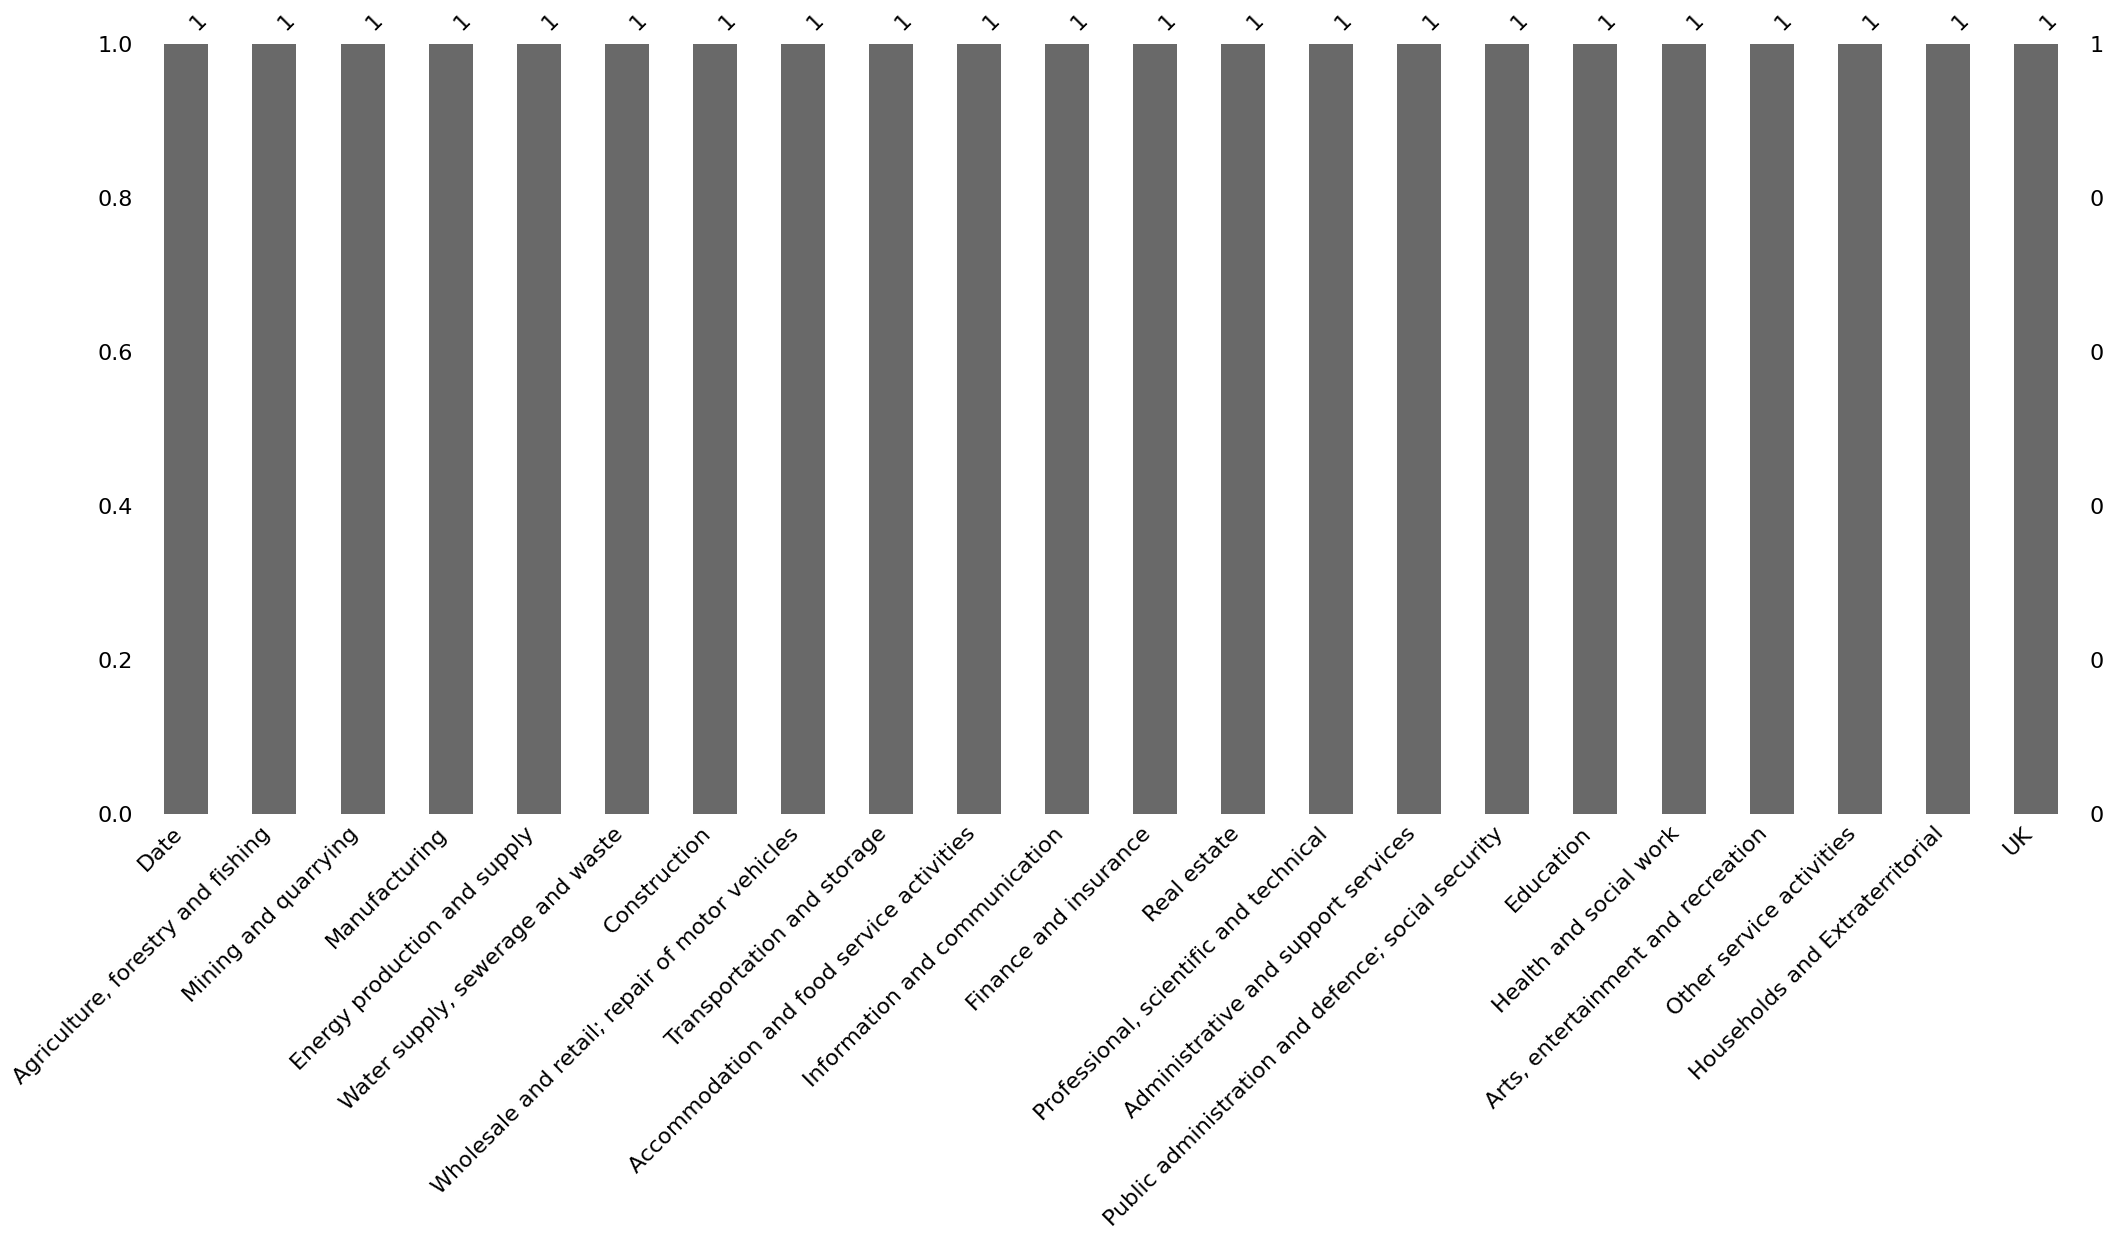

In [17]:
msno.bar(employees.sample())

/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:2950: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([dvw, 0])


<Axes: >

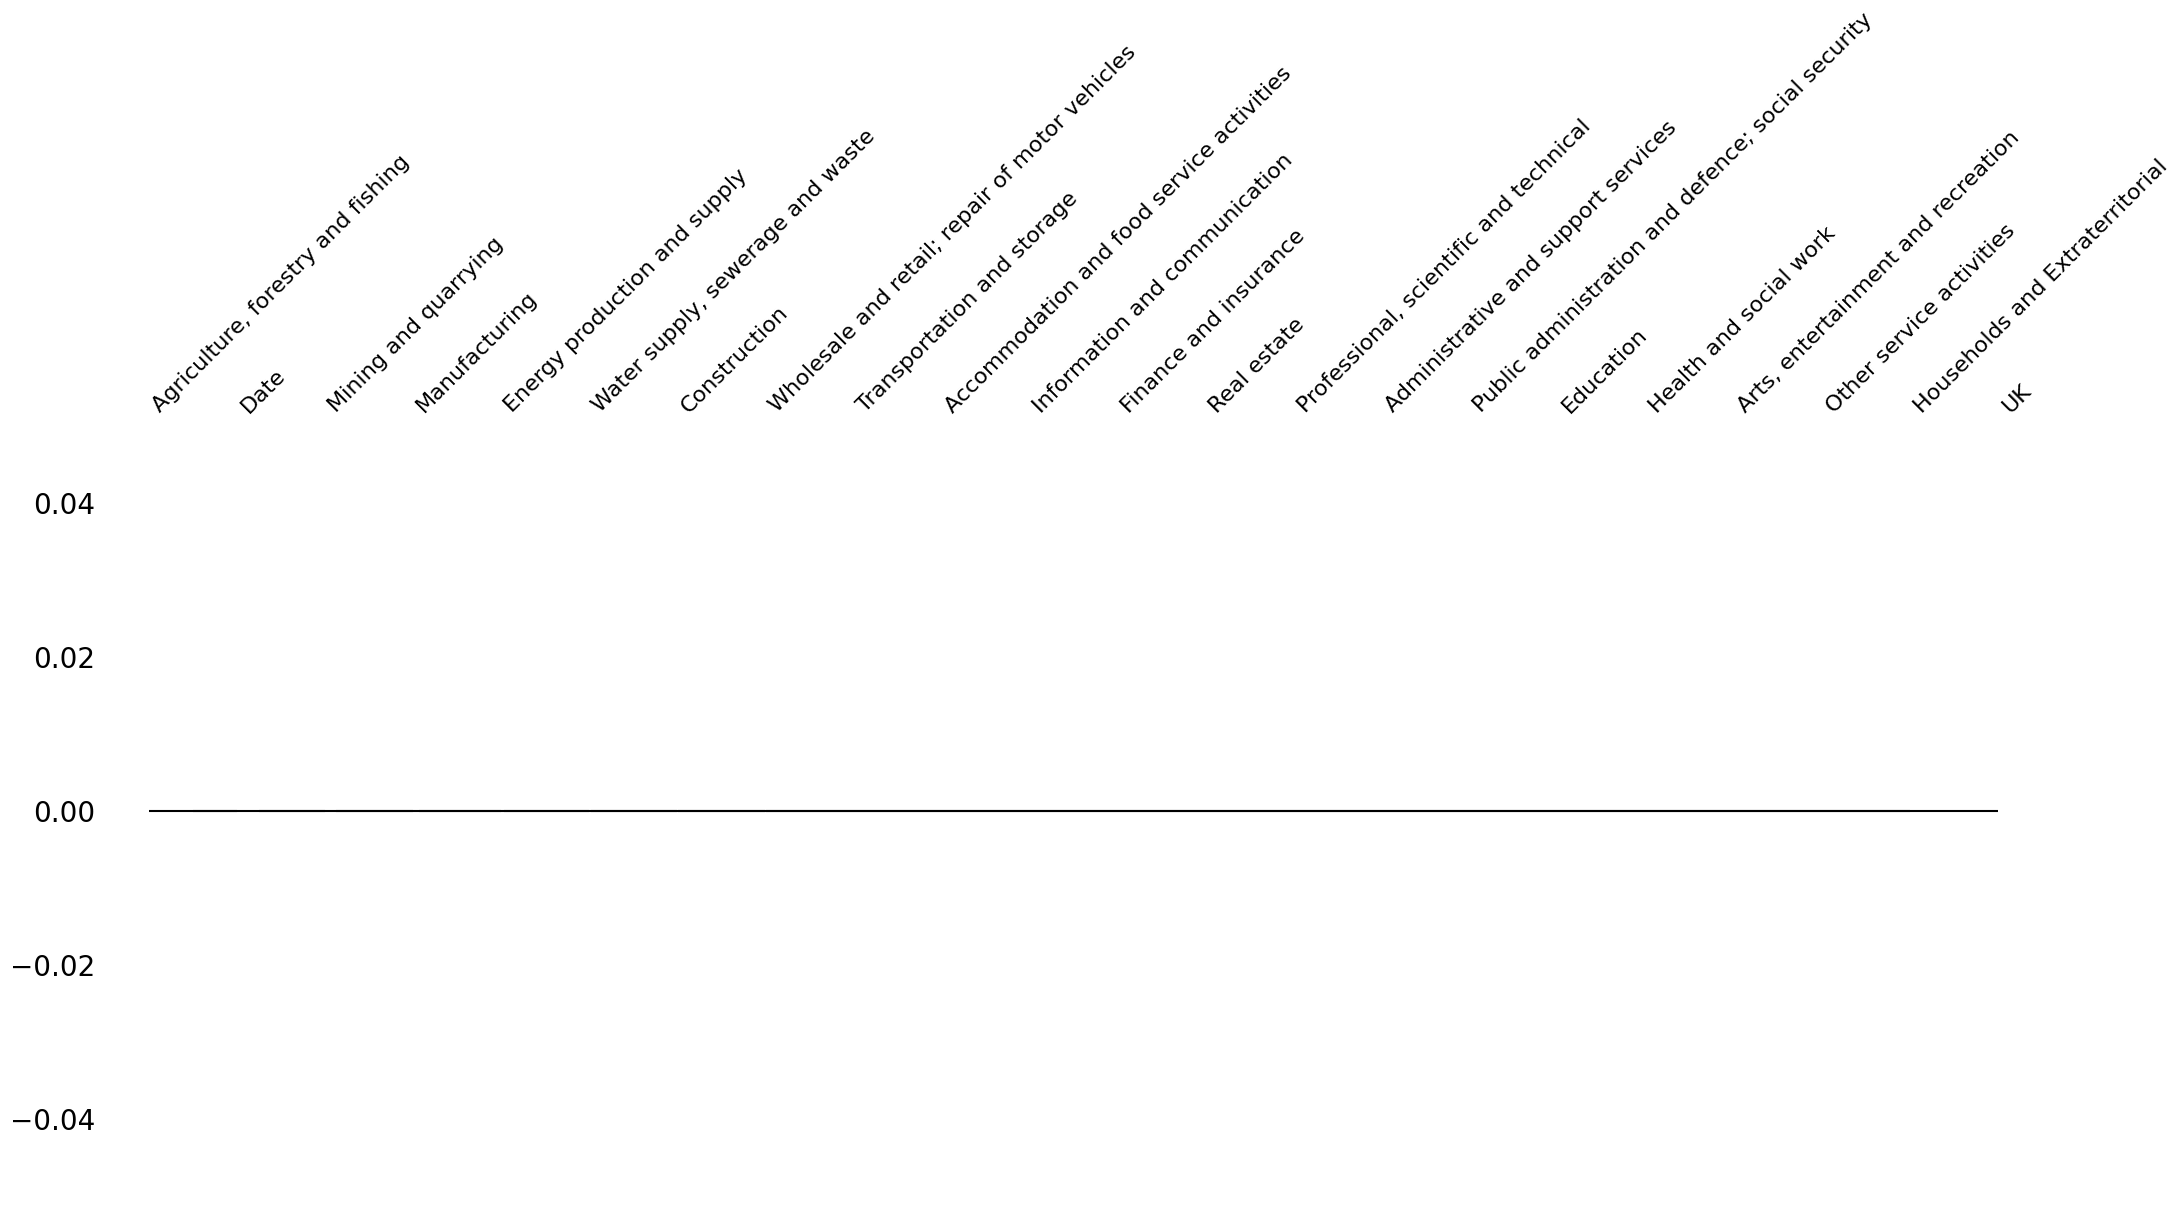

In [18]:
msno.dendrogram(employees)

In [19]:
employees.isnull().sum()

,0
Date,0
"Agriculture, forestry and fishing",0
Mining and quarrying,0
Manufacturing,0
Energy production and supply,0
"Water supply, sewerage and waste",0
Construction,0
Wholesale and retail; repair of motor vehicles,0
Transportation and storage,0
Accommodation and food service activities,0


<Axes: >

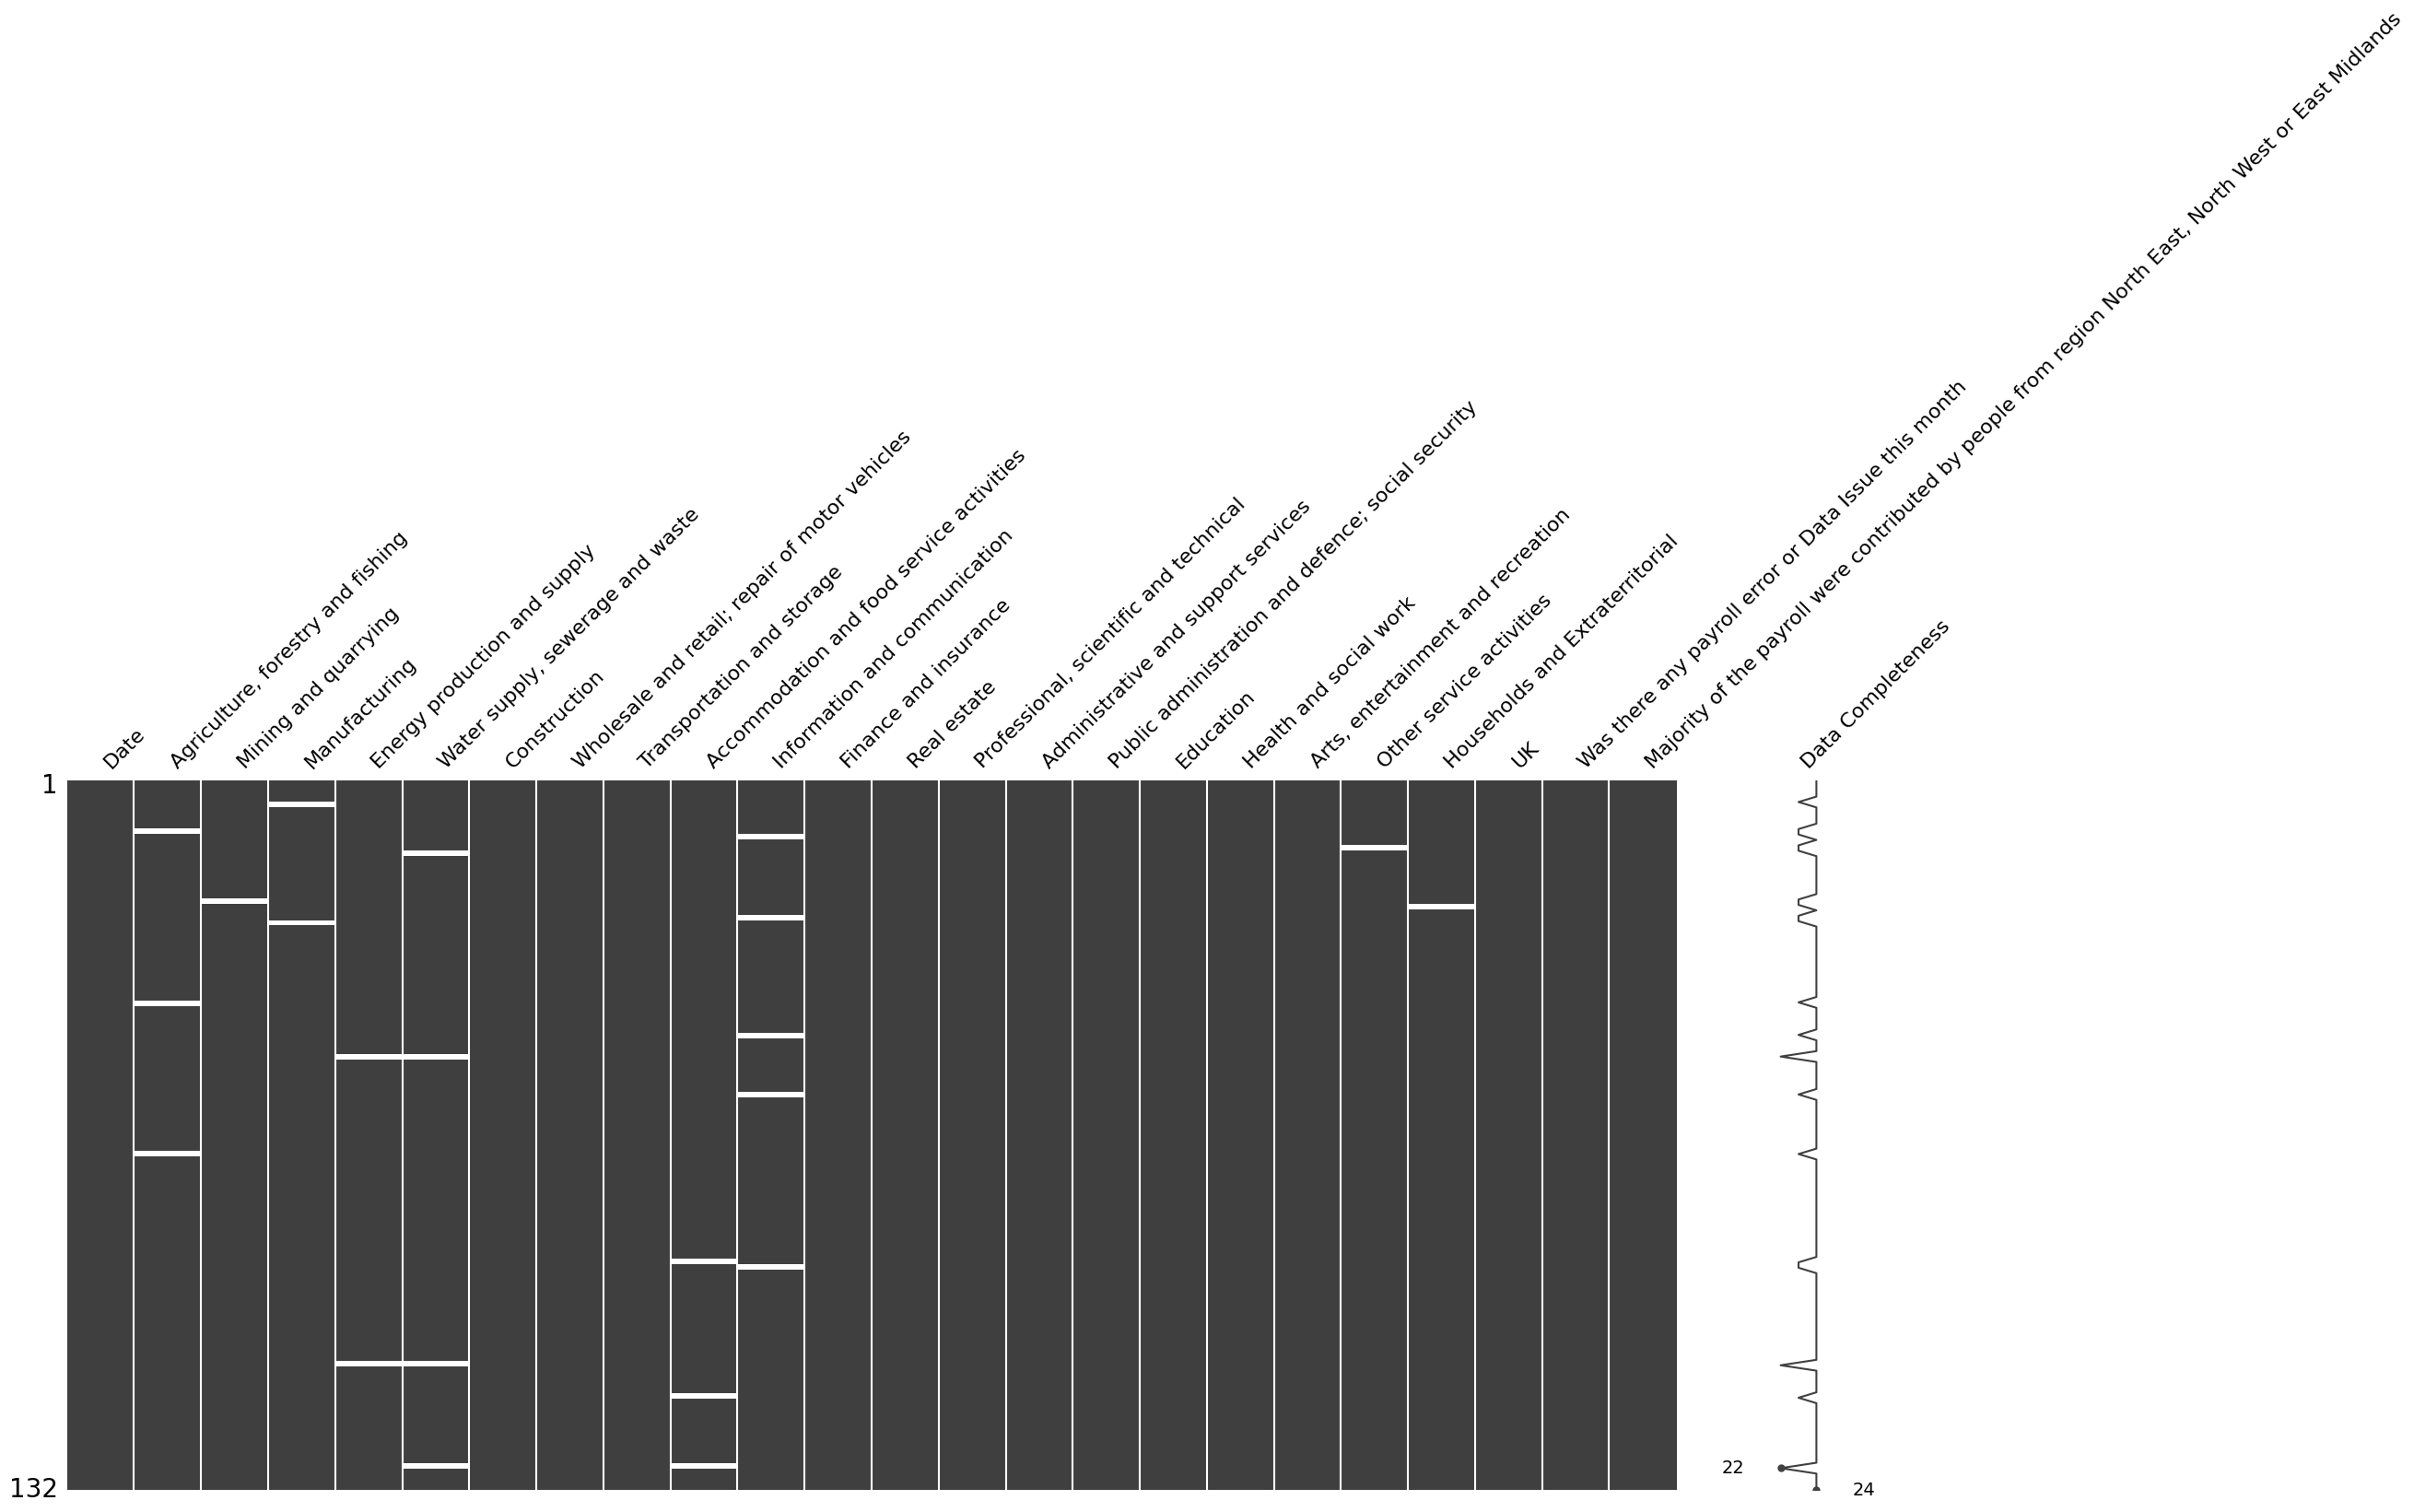

In [20]:
msno.matrix(mean_pay,labels=True)

<Axes: >

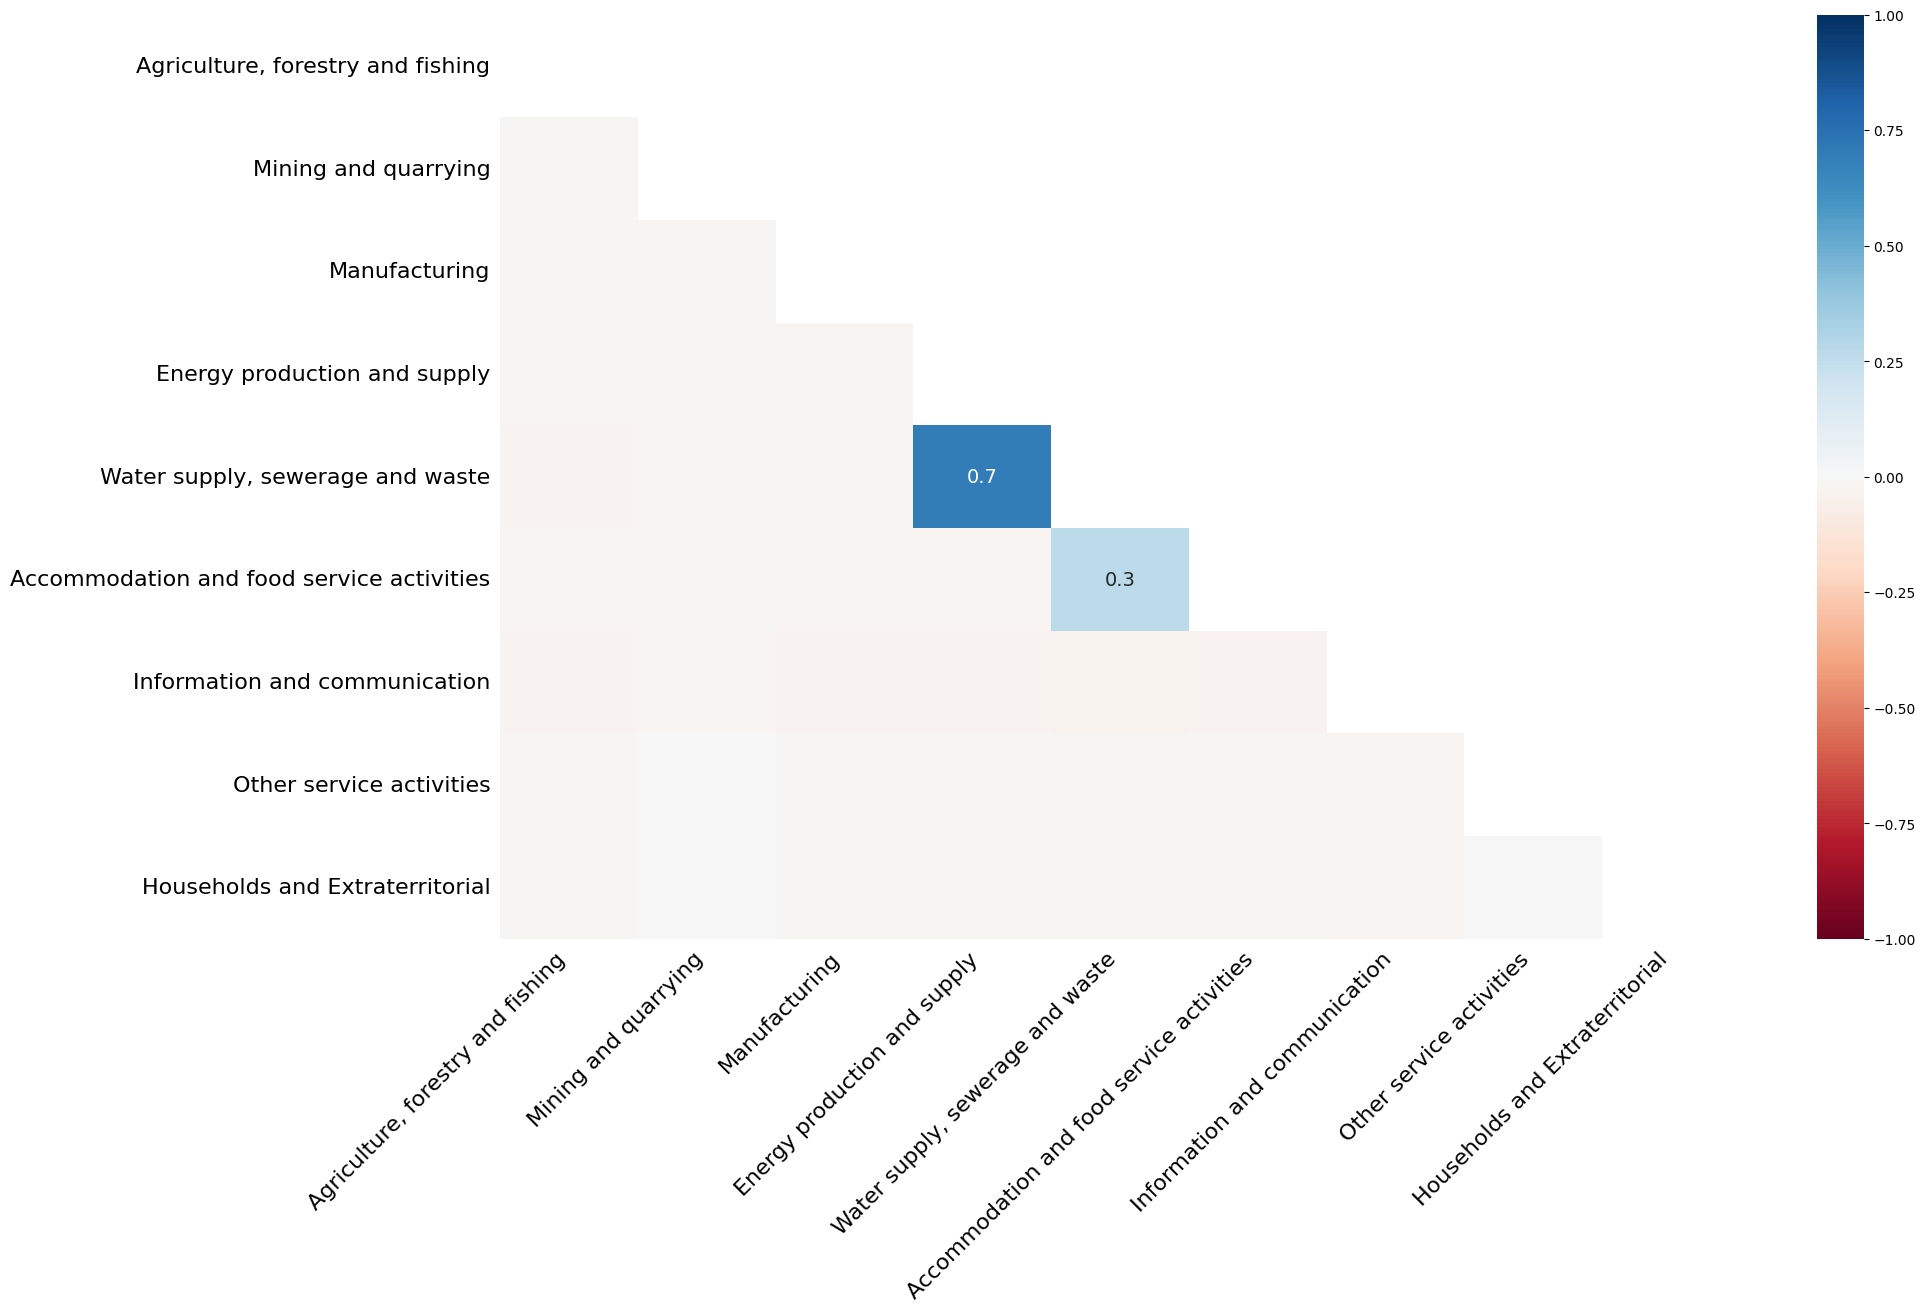

In [21]:
msno.heatmap(mean_pay)

<Axes: >

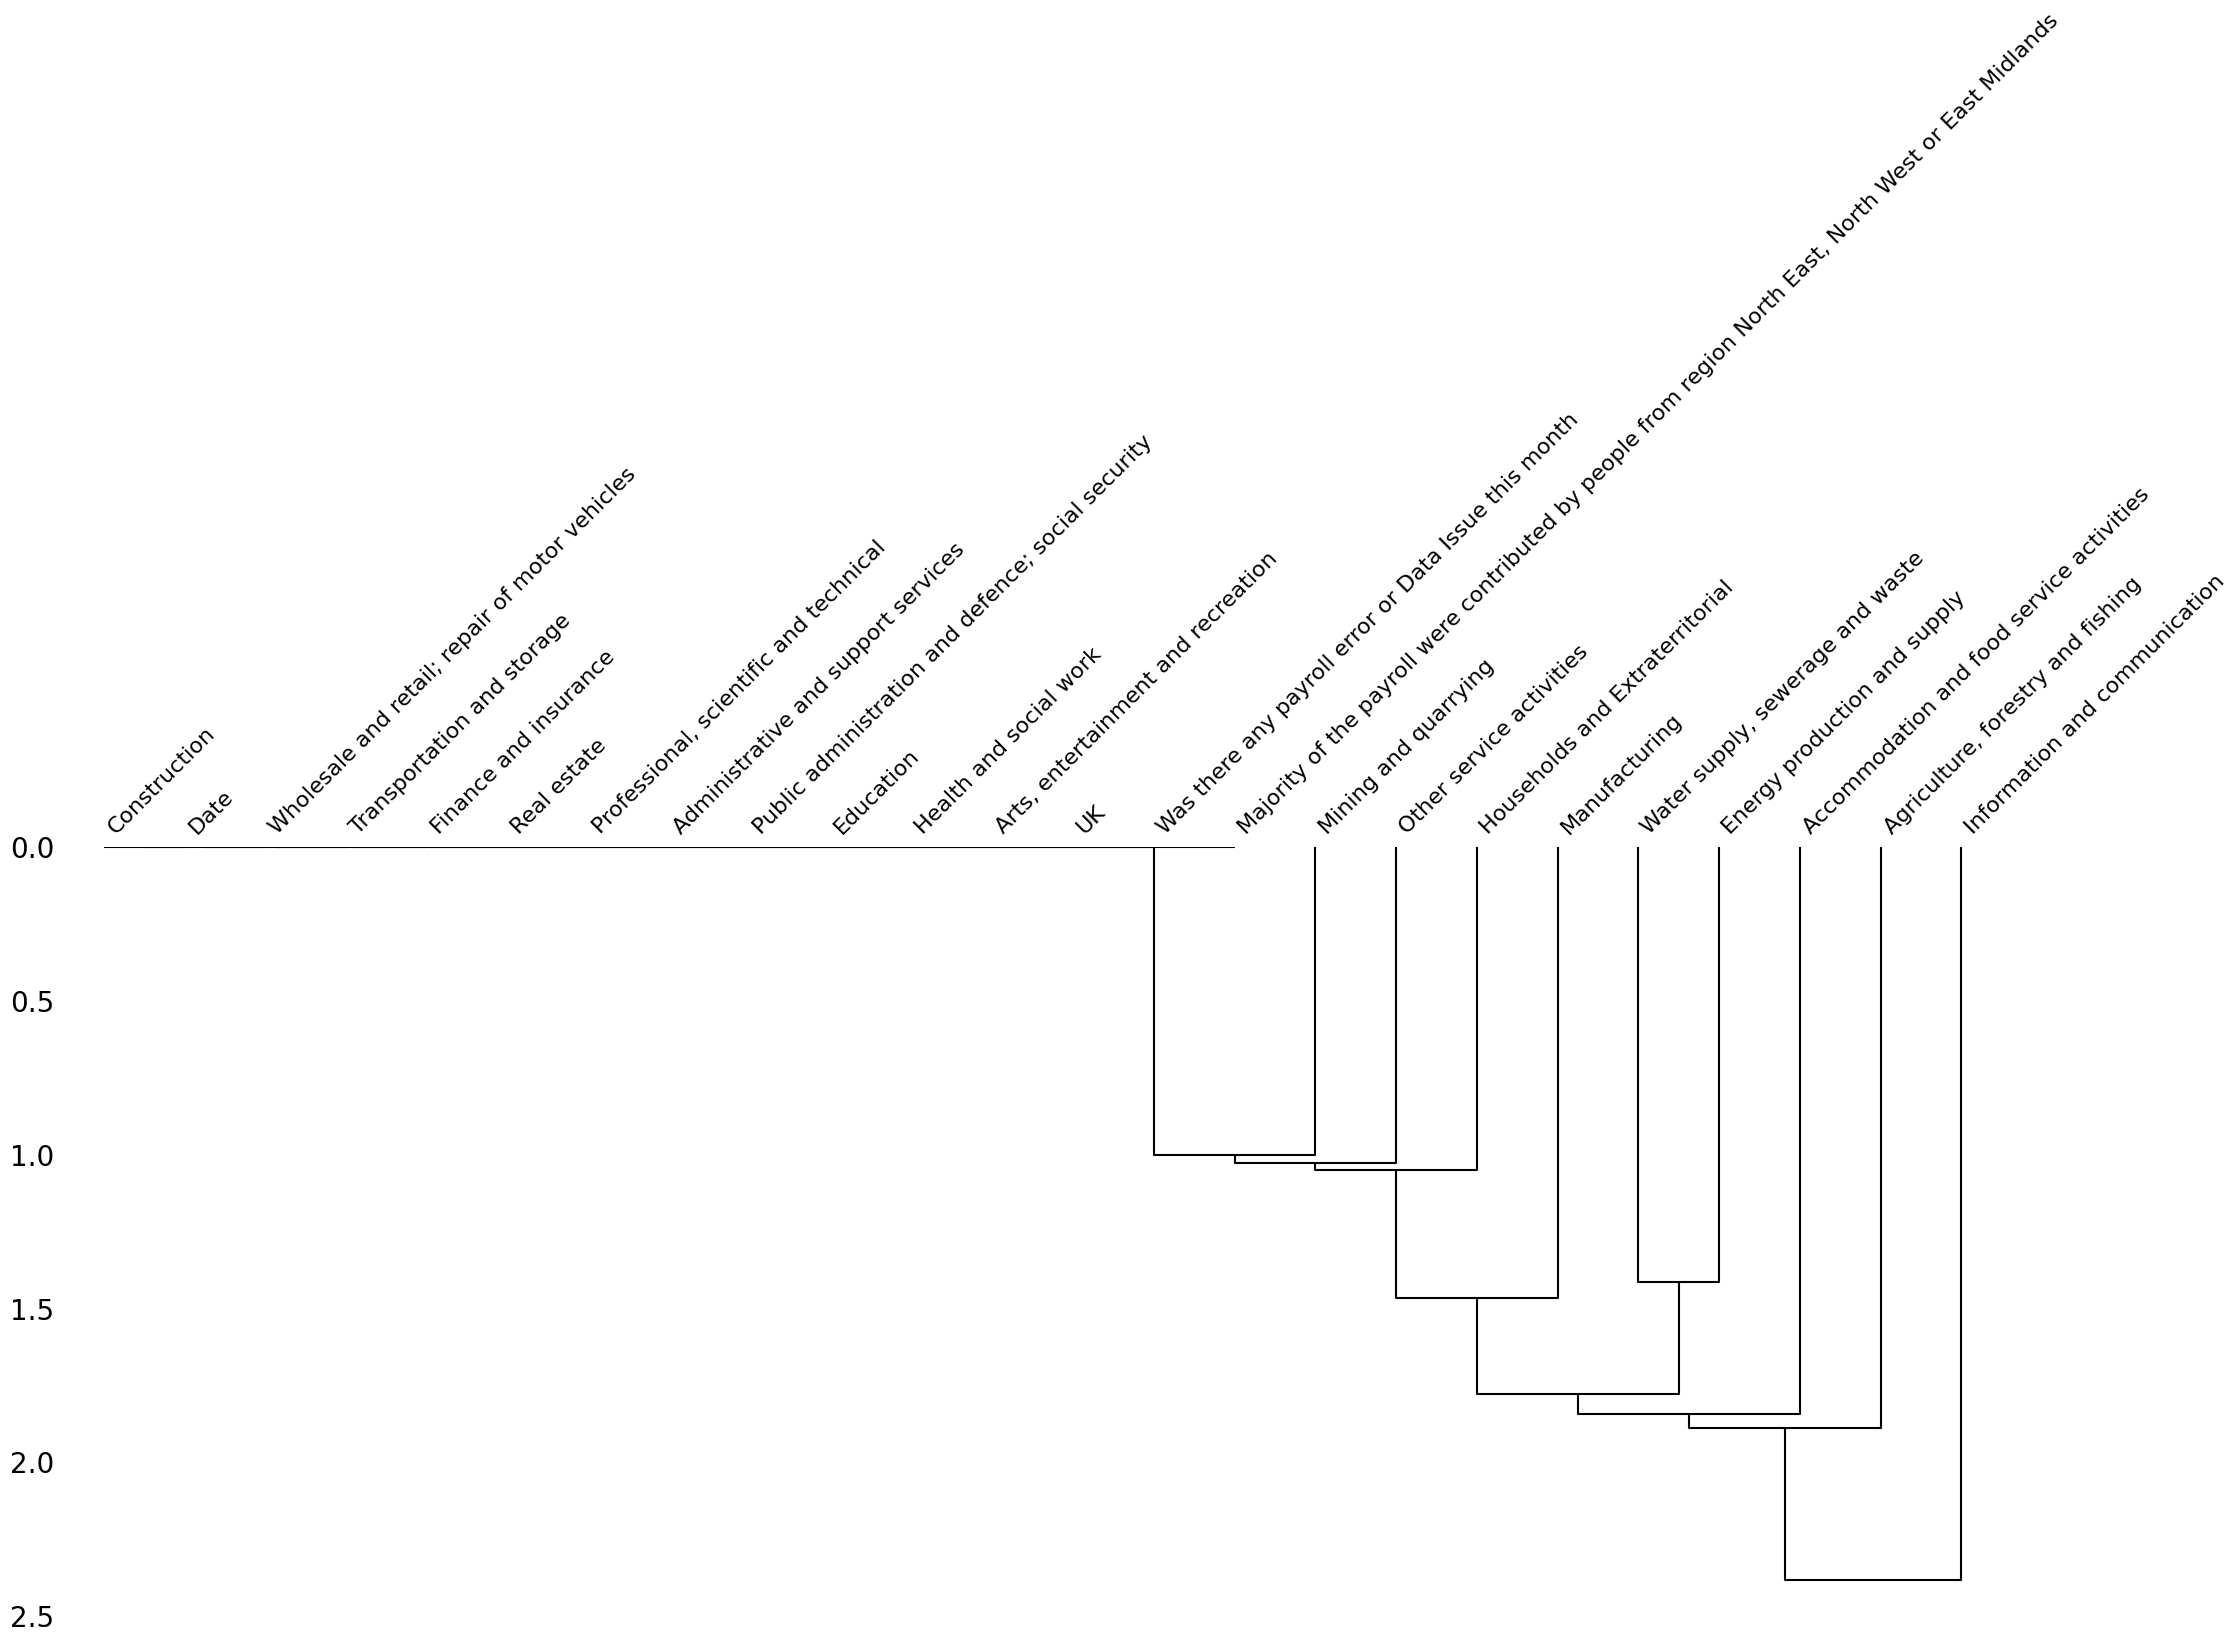

In [22]:
msno.dendrogram(mean_pay)

In [23]:
mean_pay.isnull().sum()

,0
Date,0
"Agriculture, forestry and fishing",3
Mining and quarrying,1
Manufacturing,2
Energy production and supply,2
"Water supply, sewerage and waste",4
Construction,0
Wholesale and retail; repair of motor vehicles,0
Transportation and storage,0
Accommodation and food service activities,3


convert datetime

In [24]:
employees = employees.rename(columns={employees.columns[0]: "Date"})
mean_pay = mean_pay.rename(columns={mean_pay.columns[0]: "Date"})

employees["Date"] = pd.to_datetime(employees["Date"], format="%B %Y")
mean_pay["Date"] = pd.to_datetime(mean_pay["Date"], format="%B %Y")

employees = employees.set_index("Date")

In [25]:
employees_copy = employees
employees_copy.index = pd.to_datetime(employees_copy.index)
print(employees_copy.head())
print(employees_copy.describe())

            Agriculture, forestry and fishing  Mining and quarrying  \
Date                                                                  
2014-07-01                             195597                 59358   
2014-08-01                             194663                 59607   
2014-09-01                             190243                 59905   
2014-10-01                             179615                 60040   
2014-11-01                             170266                 60157   

            Manufacturing  Energy production and supply  \
Date                                                      
2014-07-01        2337672                         92821   
2014-08-01        2342156                         92678   
2014-09-01        2363800                         92225   
2014-10-01        2362404                         92133   
2014-11-01        2372508                         92448   

            Water supply, sewerage and waste  Construction  \
Date                      

In [26]:
mean_pay_copy = mean_pay
mean_pay_copy.index = pd.to_datetime(mean_pay_copy.index)
print(mean_pay_copy.head())
print(mean_pay_copy.describe())

                                    Date  Agriculture, forestry and fishing  \
1970-01-01 00:00:00.000000000 2014-07-01                                0.0   
1970-01-01 00:00:00.000000001 2014-08-01                             1581.0   
1970-01-01 00:00:00.000000002 2014-09-01                             1595.0   
1970-01-01 00:00:00.000000003 2014-10-01                             1566.0   
1970-01-01 00:00:00.000000004 2014-11-01                             1549.0   

                               Mining and quarrying  Manufacturing  \
1970-01-01 00:00:00.000000000                4969.0         2531.0   
1970-01-01 00:00:00.000000001                4793.0         2463.0   
1970-01-01 00:00:00.000000002                4866.0         2470.0   
1970-01-01 00:00:00.000000003                4892.0         2477.0   
1970-01-01 00:00:00.000000004                4979.0            NaN   

                               Energy production and supply  \
1970-01-01 00:00:00.000000000            

##**EDA's Hypothesis**

####**Hypothesis 1**
At the industry level, sectors with higher employee counts are expected to exhibit higher mean pay over time, indicating a positive relationship between workforce size and wages. However, this relationship may vary across sectors due to structural differences.

In [27]:
cat_data = ['Date', 'Was there any payroll error or Data Issue this month', 'Majority of the payroll were contributed by people from region North East, North West or East Midlands', 'UK']

sector_employees = employees_copy.columns.difference(['Date'])
sector_mean_pay = mean_pay_copy.columns.difference(cat_data)

common_sectors = sector_employees.intersection(sector_mean_pay).tolist()
print(len(common_sectors))
print(common_sectors)

20
['Accommodation and food service activities', 'Administrative and support services', 'Agriculture, forestry and fishing', 'Arts, entertainment and recreation', 'Construction', 'Education', 'Energy production and supply', 'Finance and insurance', 'Health and social work', 'Households and Extraterritorial', 'Information and communication', 'Manufacturing', 'Mining and quarrying', 'Other service activities', 'Professional, scientific and technical', 'Public administration and defence; social security', 'Real estate', 'Transportation and storage', 'Water supply, sewerage and waste', 'Wholesale and retail; repair of motor vehicles']


In [28]:
employees_common = employees_copy.reset_index()[["Date"] + common_sectors].copy()
pay_common = mean_pay_copy.reset_index()[["Date"] + common_sectors].copy()

merged_df = pd.merge(employees_common, pay_common, on="Date", suffixes=("_employees", "_mean pay"))

print(merged_df.shape)
merged_df.head()

(132, 41)


,Date,Accommodation and food service activities_employees,Administrative and support services_employees,"Agriculture, forestry and fishing_employees","Arts, entertainment and recreation_employees",Construction_employees,Education_employees,Energy production and supply_employees,Finance and insurance_employees,Health and social work_employees,...,Information and communication_mean pay,Manufacturing_mean pay,Mining and quarrying_mean pay,Other service activities_mean pay,"Professional, scientific and technical_mean pay",Public administration and defence; social security_mean pay,Real estate_mean pay,Transportation and storage_mean pay,"Water supply, sewerage and waste_mean pay",Wholesale and retail; repair of motor vehicles_mean pay
0,2014-07-01,1787337,2321467,195597,528033,1079928,2975889,92821,1069654,3419006,...,3410.0,2531.0,4969.0,1545.0,2865,2409,2264,2450,2543.0,1627
1,2014-08-01,1801181,2316466,194663,539577,1092236,2901803,92678,1068357,3433116,...,3405.0,2463.0,4793.0,1557.0,2799,2371,2158,2415,2381.0,1614
2,2014-09-01,1790801,2346129,190243,539594,1099190,2903446,92225,1065558,3435981,...,3316.0,2470.0,4866.0,1521.0,2805,2377,2149,2395,2394.0,1602
3,2014-10-01,1764657,2366977,179615,532466,1102251,2939361,92133,1060081,3435950,...,3270.0,2477.0,4892.0,1531.0,2821,2372,2130,2407,2400.0,1633
4,2014-11-01,1768185,2389944,170266,528441,1109811,2980481,92448,1062245,3448671,...,3308.0,NaN,4979.0,1566.0,2875,2360,2153,2440,2426.0,1627


In [29]:
correlation_results = []

for sector in common_sectors:
    emp_col = f"{sector}_employees"
    pay_col = f"{sector}_mean pay"

    temp = merged_df[[emp_col, pay_col]].dropna()

    if len(temp) > 1:
        corr = temp[emp_col].corr(temp[pay_col])
        correlation_results.append([sector, corr])

corr_df = pd.DataFrame(correlation_results, columns=["Sector", "PearsonCorrelation"])
corr_df = corr_df.sort_values("PearsonCorrelation", ascending=False)

corr_df

,Sector,PearsonCorrelation
8,Health and social work,0.976747
18,"Water supply, sewerage and waste",0.932754
14,"Professional, scientific and technical",0.917449
5,Education,0.902415
16,Real estate,0.899423
10,Information and communication,0.878627
4,Construction,0.839260
17,Transportation and storage,0.802453
0,Accommodation and food service activities,0.791006
13,Other service activities,0.721526


EDA 1 - Graph 1: Bar Chart of sector correlation

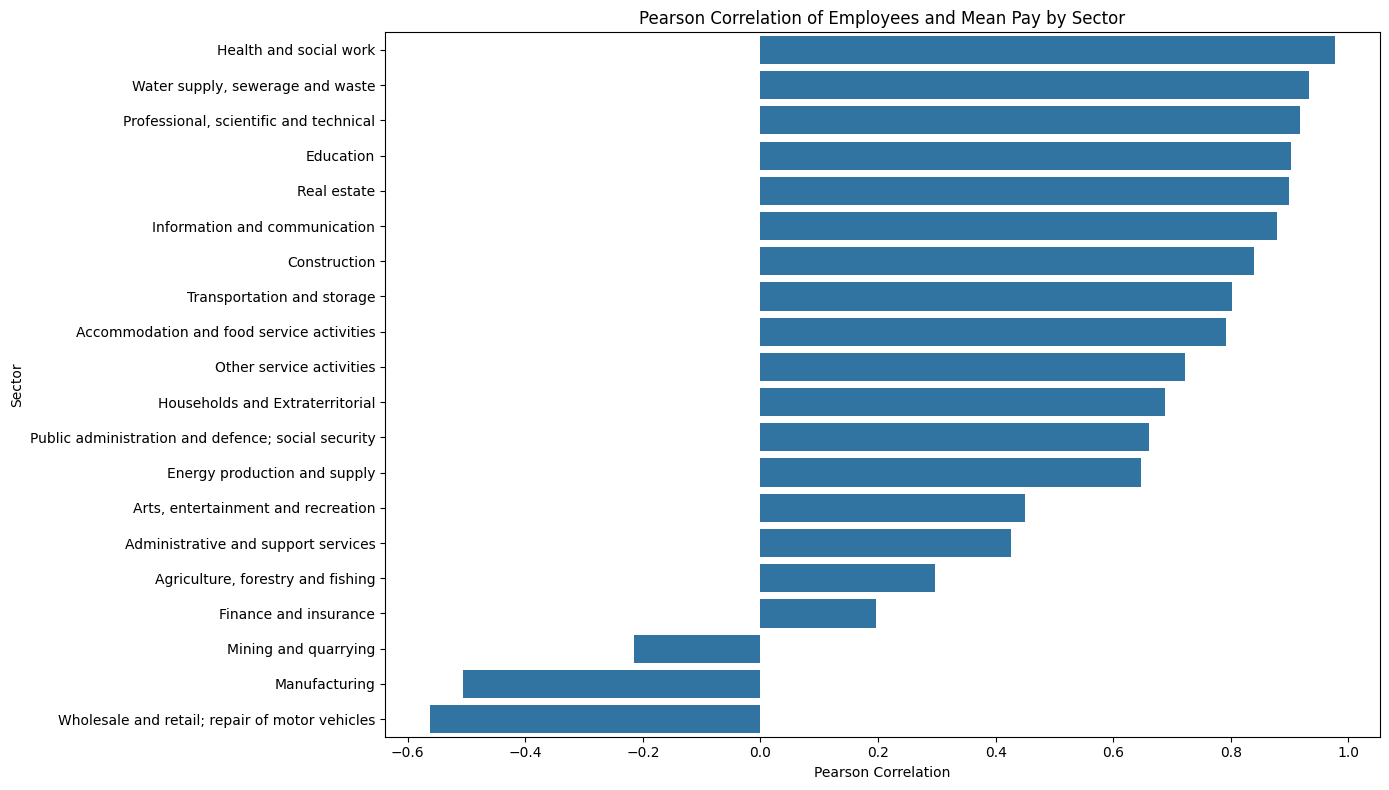

In [30]:
plt.figure(figsize=(14, 8))
sns.barplot(data=corr_df, y="Sector", x="PearsonCorrelation")
plt.title("Pearson Correlation of Employees and Mean Pay by Sector")
plt.xlabel("Pearson Correlation")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

EDA 1: Graph 2 - Top Bottom Sectors comparison

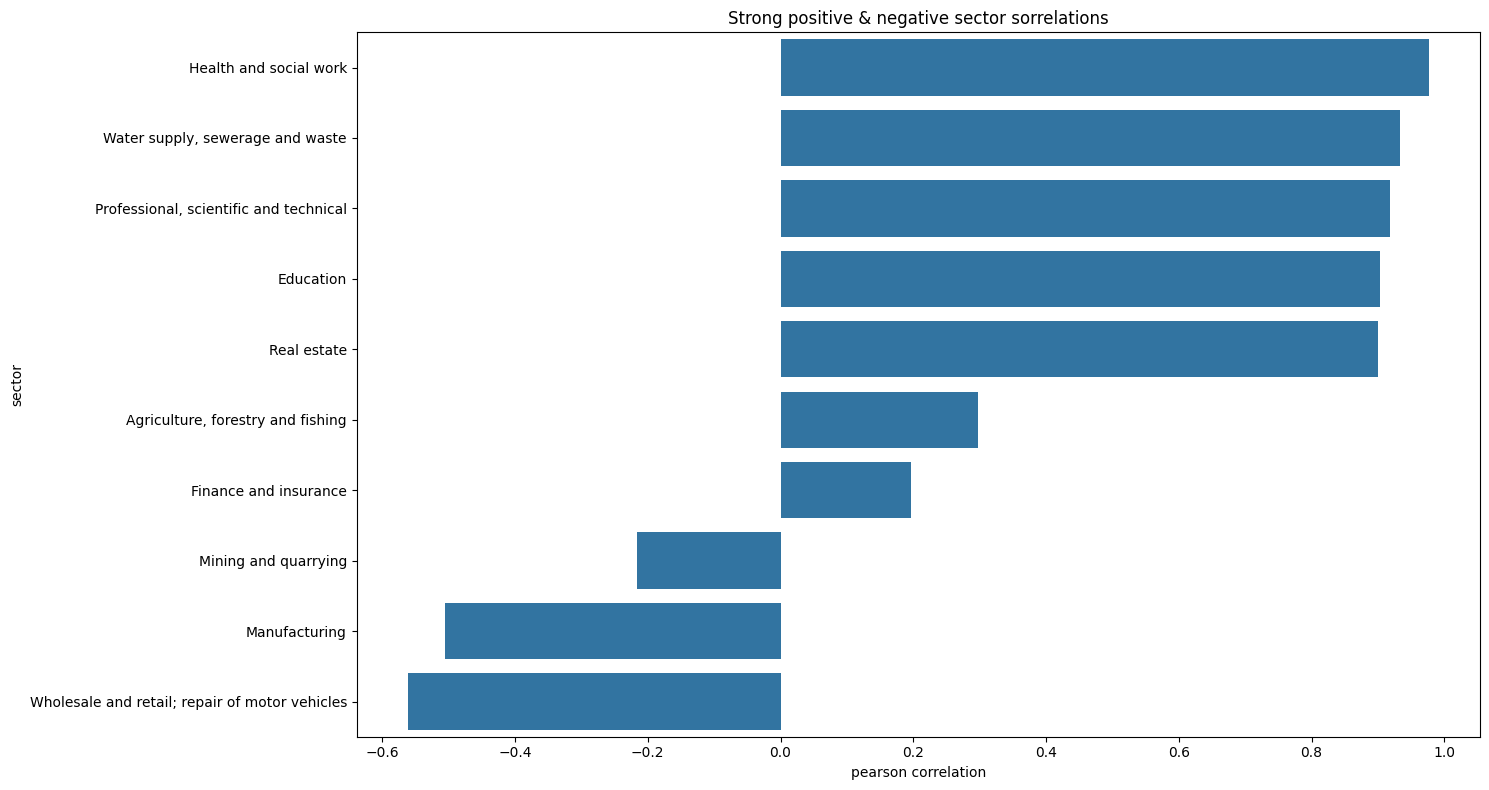

In [31]:
headtail_corr = pd.concat([corr_df.head(5), corr_df.tail(5)])
plt.figure(figsize=(15, 8))
sns.barplot(data=headtail_corr, x="PearsonCorrelation", y="Sector")
plt.title("Strong positive & negative sector sorrelations")
plt.xlabel("pearson correlation")
plt.ylabel("sector")
plt.tight_layout()
plt.show()

EDA 1: Graph 3 - scatterplot for a strong positive sector

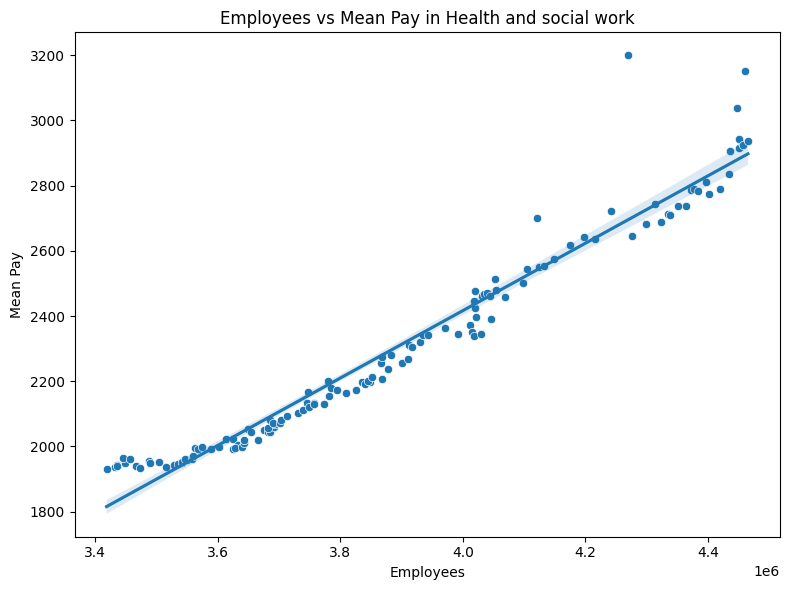

In [32]:
stpos_sectore = corr_df.iloc[0]["Sector"]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=merged_df,
    x=f"{stpos_sectore}_employees",
    y=f"{stpos_sectore}_mean pay"
)
sns.regplot(
    data=merged_df,
    x=f"{stpos_sectore}_employees",
    y=f"{stpos_sectore}_mean pay",
    scatter=False
)
plt.title(f"Employees vs Mean Pay in {stpos_sectore}")
plt.xlabel("Employees")
plt.ylabel("Mean Pay")
plt.tight_layout()
plt.show()

EDA 1: Graph 4 - scatterplot negative/weak sector

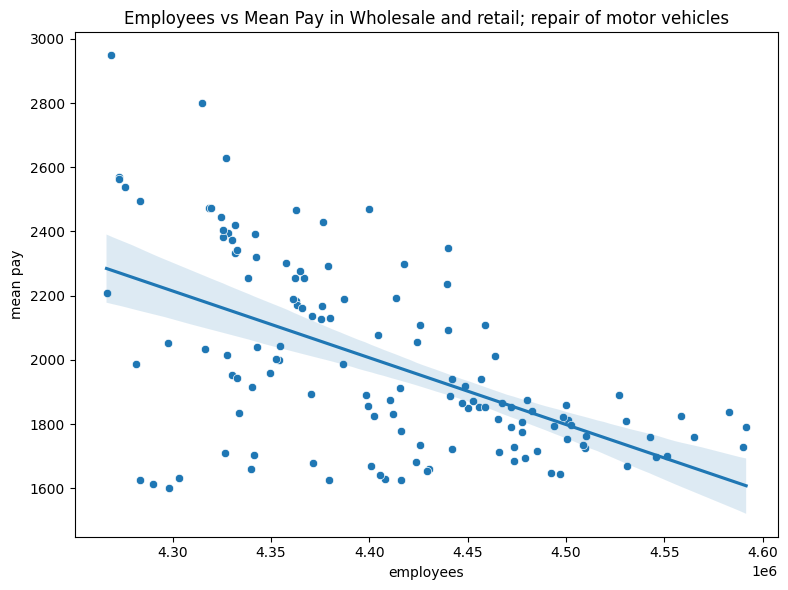

In [33]:
weaksector=corr_df.iloc[-1]["Sector"]
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=merged_df,
    x=f"{weaksector}_employees",
    y=f"{weaksector}_mean pay"
)
sns.regplot(
    data=merged_df,
    x=f"{weaksector}_employees",
    y=f"{weaksector}_mean pay",
    scatter=False
)
plt.title(f"Employees vs Mean Pay in {weaksector}")
plt.xlabel("employees")
plt.ylabel("mean pay")
plt.tight_layout()
plt.show()

EDA 1: Graph 5 - Correlation Heatmap selected sectors

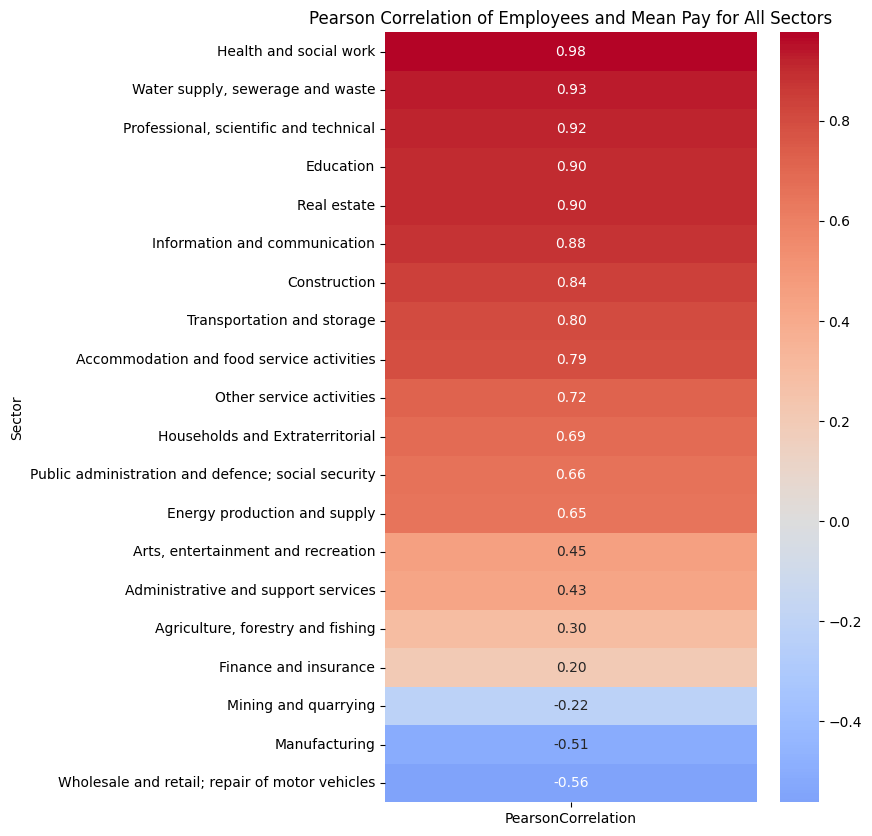

In [34]:
plt.figure(figsize=(6, 10))
sns.heatmap(corr_df.set_index('Sector'), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Pearson Correlation of Employees and Mean Pay for All Sectors")
plt.ylabel("Sector")
plt.show()

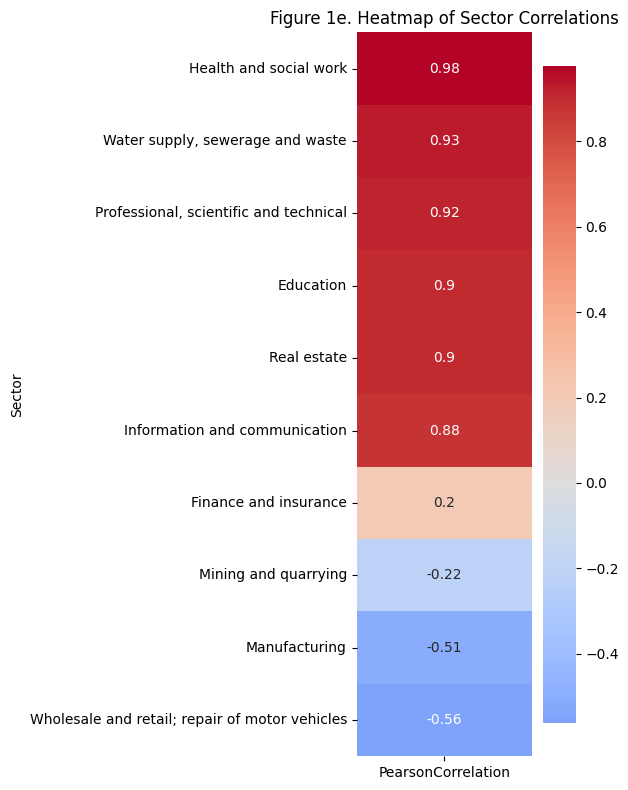

In [35]:
selectheatmap = corr_df["Sector"].head(6).tolist() + corr_df["Sector"].tail(4).tolist()

heatmap1 = corr_df[corr_df["Sector"].isin(selectheatmap)].copy()
heatmap1 = heatmap1.set_index("Sector")

plt.figure(figsize=(6, 8))
sns.heatmap(heatmap1, annot=True, cmap="coolwarm", center=0)
plt.title("Figure 1e. Heatmap of Sector Correlations")
plt.tight_layout()
plt.show()

##**EDA 2 - Hypothesis 2**

###**Hypothesis 2:**
At the aggregate level, higher total PAYE employment is expected to be associated with higher average mean pay over time, indicating a positive macro-level relationship between workforce size and wages.

In [36]:
monthly_agg = pd.DataFrame({
    "Date": employees_common["Date"],
    "TotalEmployees": employees_common[common_sectors].sum(axis=1),
    "AvgMeanPay": pay_common[common_sectors].mean(axis=1)
})

monthly_agg = monthly_agg.sort_values("Date")

monthly_agg.head()

,Date,TotalEmployees,AvgMeanPay
0,2014-07-01,26893851,2319.600000
1,2014-08-01,26865396,2370.550000
2,2014-09-01,26945379,2358.000000
3,2014-10-01,26965180,2346.750000
4,2014-11-01,27159526,2382.631579


In [37]:
overall_corr = monthly_agg["TotalEmployees"].corr(monthly_agg["AvgMeanPay"])
print("Pearson correlation Overall :", round(overall_corr, 4))

Pearson correlation Overall : 0.8364


EDA 2: Graph 1 - Line plot total employees over time

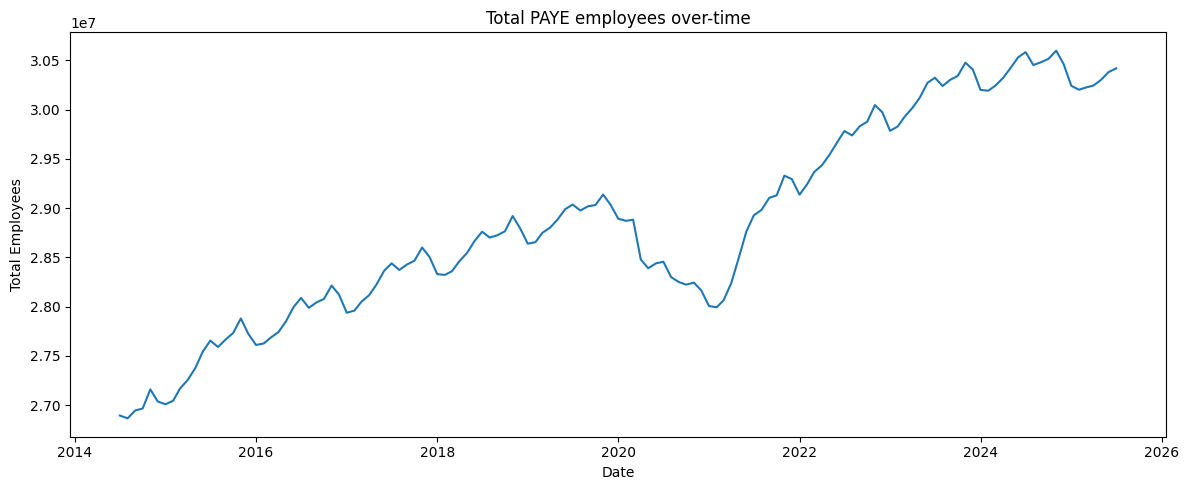

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_agg["Date"], monthly_agg["TotalEmployees"])
plt.title("Total PAYE employees over-time")
plt.xlabel("Date")
plt.ylabel("Total Employees")
plt.tight_layout()
plt.show()

EDA 2: Graph 2 - line plot average mean pay over time

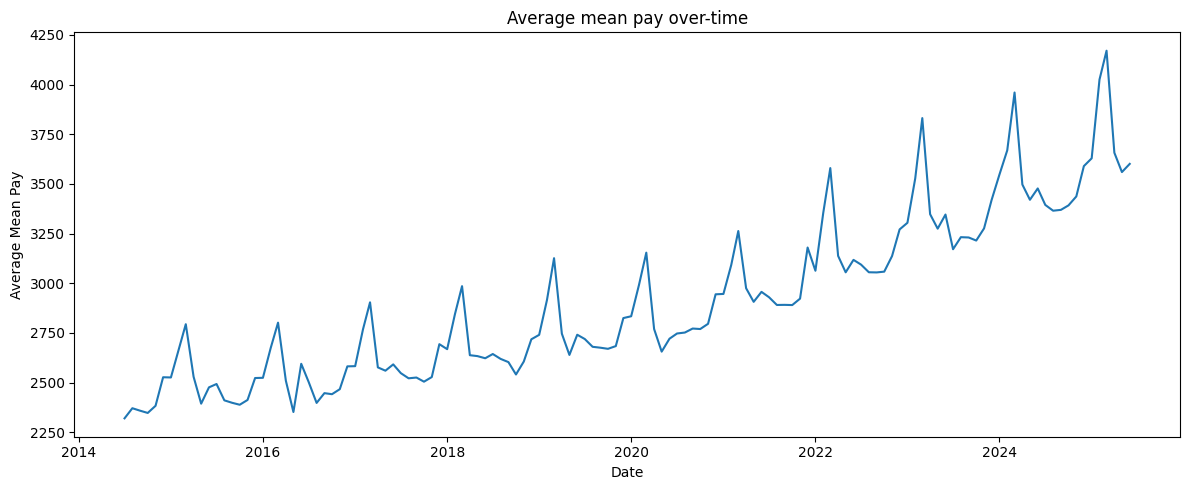

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_agg["Date"], monthly_agg["AvgMeanPay"])
plt.title("Average mean pay over-time")
plt.xlabel("Date")
plt.ylabel("Average Mean Pay")
plt.tight_layout()
plt.show()

EDA 2: Graph 3 - Scatterplot with regression line

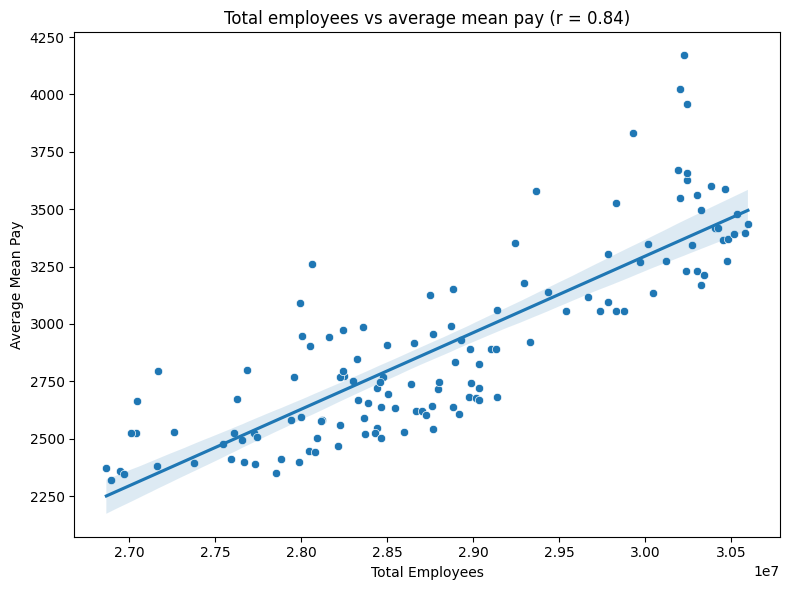

In [40]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=monthly_agg, x="TotalEmployees", y="AvgMeanPay")
sns.regplot(data=monthly_agg, x="TotalEmployees", y="AvgMeanPay", scatter=False)
plt.title(f"Total employees vs average mean pay (r = {overall_corr:.2f})")
plt.xlabel("Total Employees")
plt.ylabel("Average Mean Pay")
plt.tight_layout()
plt.show()

EDA 2: Graph 4 - dual trend comparison after standardising

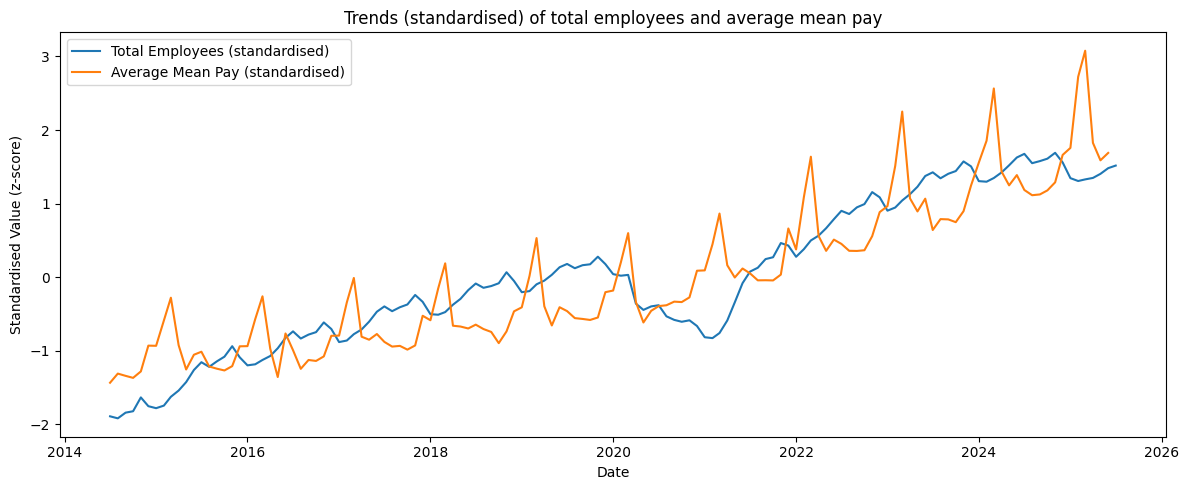

In [41]:
monthly_agg["Employees_z"] = (monthly_agg["TotalEmployees"] - monthly_agg["TotalEmployees"].mean()) / monthly_agg["TotalEmployees"].std()
monthly_agg["Pay_z"] = (monthly_agg["AvgMeanPay"] - monthly_agg["AvgMeanPay"].mean()) / monthly_agg["AvgMeanPay"].std()

plt.figure(figsize=(12, 5))
plt.plot(monthly_agg["Date"], monthly_agg["Employees_z"], label="Total Employees (standardised)")
plt.plot(monthly_agg["Date"], monthly_agg["Pay_z"], label="Average Mean Pay (standardised)")
plt.title("Trends (standardised) of total employees and average mean pay")
plt.xlabel("Date")
plt.ylabel("Standardised Value (z-score)")
plt.legend()
plt.tight_layout()
plt.show()

EDA 2: Graph 5 - rolling mean trend

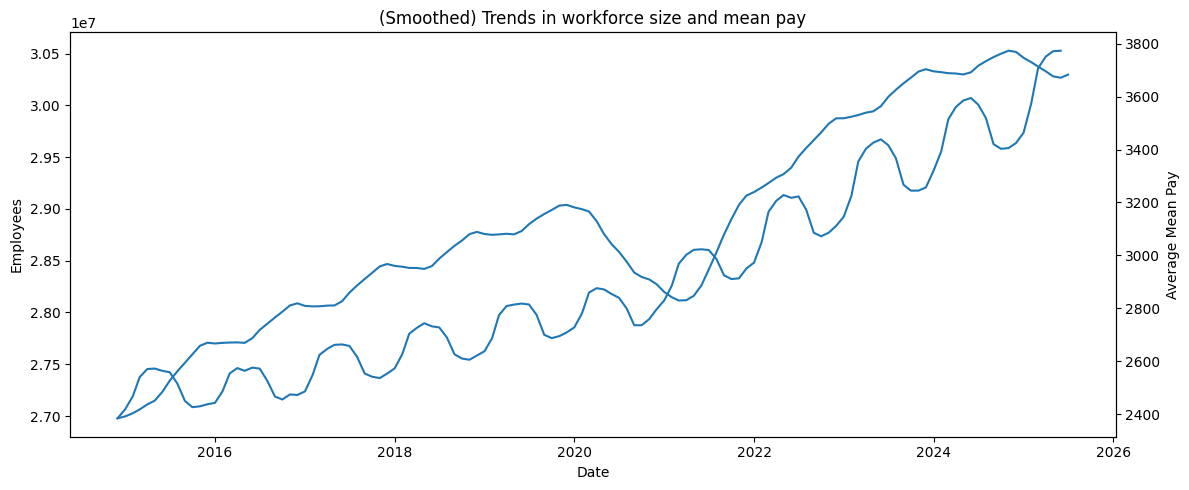

In [42]:
monthly_agg["Employees_roll"] = monthly_agg["TotalEmployees"].rolling(window=6).mean()
monthly_agg["Pay_roll"] = monthly_agg["AvgMeanPay"].rolling(window=6).mean()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_agg["Date"], monthly_agg["Employees_roll"], label="Employees (6-month rolling mean)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Employees")

ax2 = ax1.twinx()
ax2.plot(monthly_agg["Date"], monthly_agg["Pay_roll"], label="Pay (6-month rolling mean)")
ax2.set_ylabel("Average Mean Pay")

plt.title("(Smoothed) Trends in workforce size and mean pay")
plt.tight_layout()
plt.show()

**Task 3: Data Pre-Processing**

**TECHNIQUE 1: Missing value imputation – numeric attribute**

The Mean Pay (Industry) dataset contains missing values and zero entries likely caused by reporting gaps. Applying a combination of linear interpolation and mean imputation is expected to produce a complete and continuous numeric dataset while preserving the overall distribution.

In [43]:
mean_pay.isnull().sum()

,0
Date,0
"Agriculture, forestry and fishing",3
Mining and quarrying,1
Manufacturing,2
Energy production and supply,2
"Water supply, sewerage and waste",4
Construction,0
Wholesale and retail; repair of motor vehicles,0
Transportation and storage,0
Accommodation and food service activities,3


In [44]:
mean_pay[mean_pay['Agriculture, forestry and fishing'].isnull()]

,Date,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,...,Administrative and support services,Public administration and defence; social security,Education,Health and social work,"Arts, entertainment and recreation",Other service activities,Households and Extraterritorial,UK,Was there any payroll error or Data Issue this month,"Majority of the payroll were contributed by people from region North East, North West or East Midlands"
1970-01-01 00:00:00.000000009,2015-04-01,NaN,5445.0,2555.0,3799.0,2550.0,2391,1711,2481,1128.0,...,1813,2421,1962,1955,1790,1563.0,1098.0,2213,yes,North East
1970-01-01 00:00:00.000000041,2017-12-01,NaN,5325.0,2785.0,3615.0,2626.0,2721,1791,2565,1248.0,...,1970,2500,2068,2057,1965,1698.0,1199.0,2380,yes,North East
1970-01-01 00:00:00.000000069,2020-04-01,NaN,5749.0,2707.0,4364.0,2632.0,2310,1832,2534,1118.0,...,2135,2665,2207,2256,1933,1738.0,1334.0,2437,yes,North East


In [45]:
mean_pay.isnull().mean()

,0
Date,0.000000
"Agriculture, forestry and fishing",0.022727
Mining and quarrying,0.007576
Manufacturing,0.015152
Energy production and supply,0.015152
"Water supply, sewerage and waste",0.030303
Construction,0.000000
Wholesale and retail; repair of motor vehicles,0.000000
Transportation and storage,0.000000
Accommodation and food service activities,0.022727


In [46]:
cols_with_nan = [col for col in common_sectors
                 if mean_pay[col].isnull().sum() > 0]


print("Columns missing values:")
print(mean_pay[cols_with_nan].isnull().sum())

Columns missing values:
Accommodation and food service activities    3
Agriculture, forestry and fishing            3
Energy production and supply                 2
Households and Extraterritorial              1
Information and communication                5
Manufacturing                                2
Mining and quarrying                         1
Other service activities                     1
Water supply, sewerage and waste             4
dtype: int64



───────────────────────────────────────────────────────
Column : Accommodation and food service activities
  Mean   : 1326.74
  Median : 1270.00
  EOD    : 1867.95  (mean + 3×std)
  Missing: 3


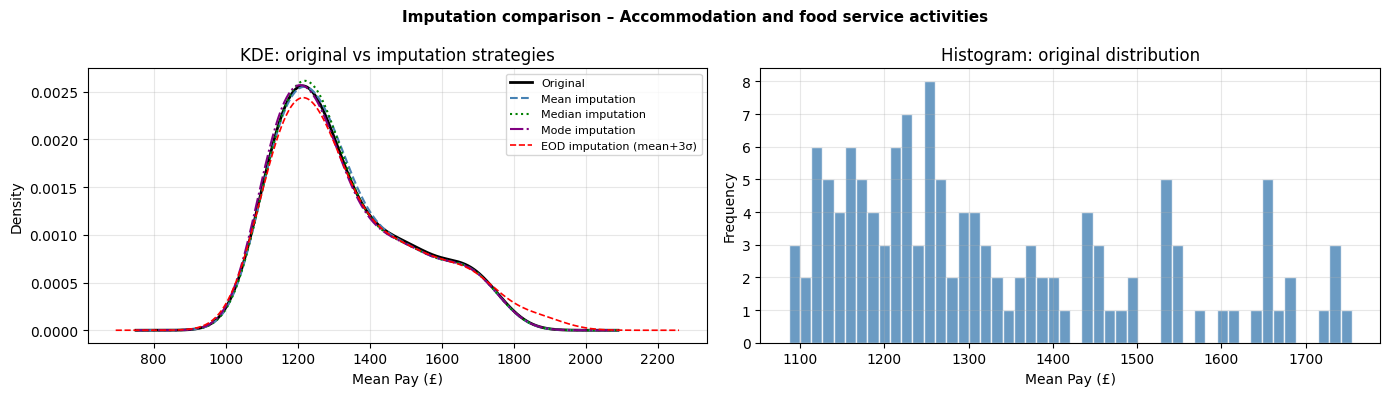


───────────────────────────────────────────────────────
Column : Agriculture, forestry and fishing
  Mean   : 1868.34
  Median : 1834.00
  EOD    : 2786.90  (mean + 3×std)
  Missing: 3


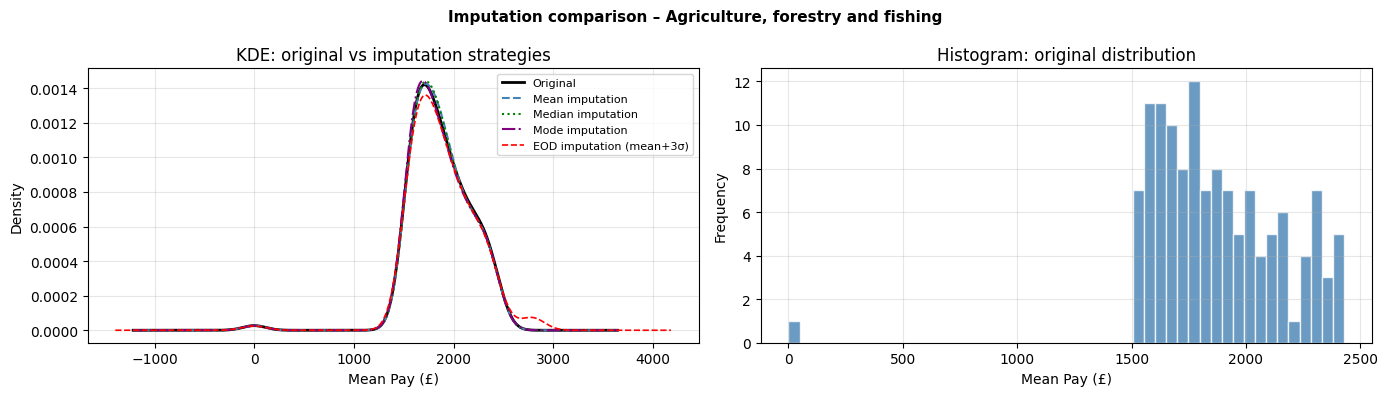


───────────────────────────────────────────────────────
Column : Energy production and supply
  Mean   : 4287.53
  Median : 4115.50
  EOD    : 6379.68  (mean + 3×std)
  Missing: 2


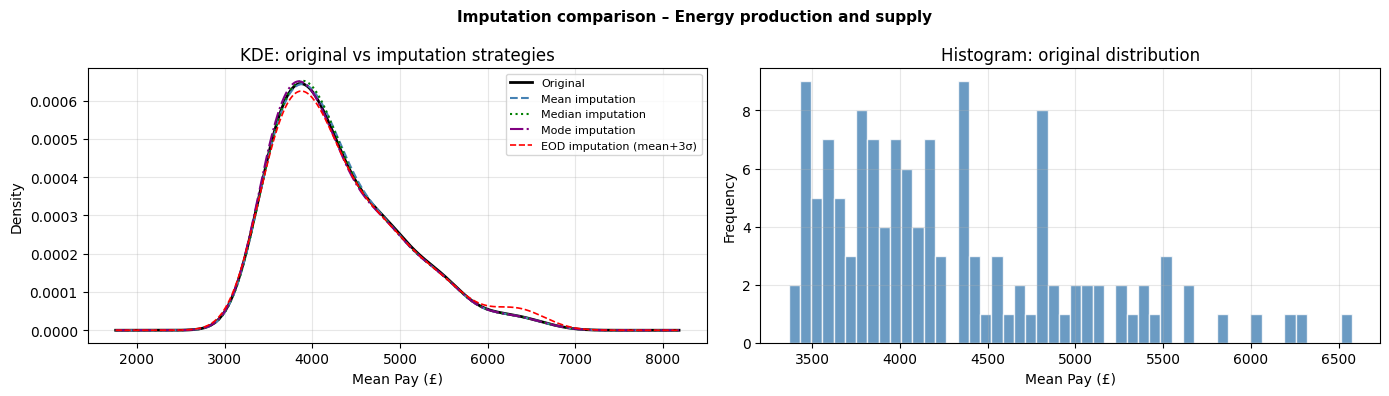


───────────────────────────────────────────────────────
Column : Households and Extraterritorial
  Mean   : 1325.75
  Median : 1269.00
  EOD    : 1858.04  (mean + 3×std)
  Missing: 1


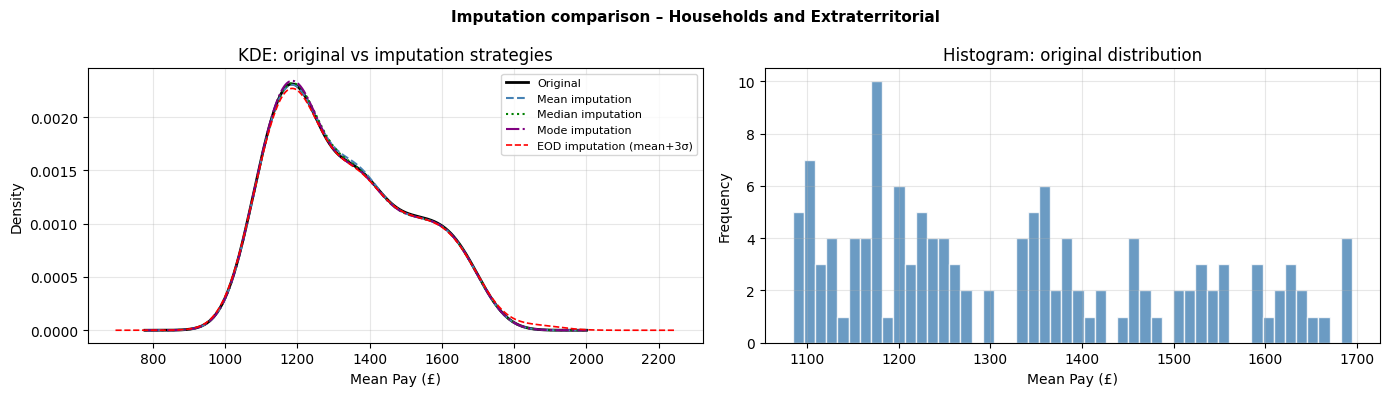


───────────────────────────────────────────────────────
Column : Information and communication
  Mean   : 4298.49
  Median : 4119.00
  EOD    : 6538.16  (mean + 3×std)
  Missing: 5


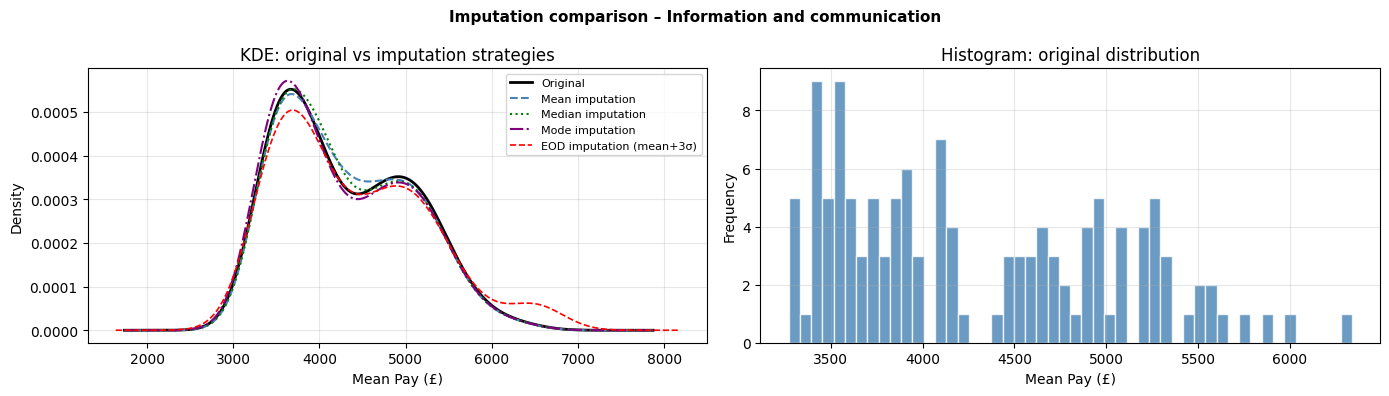


───────────────────────────────────────────────────────
Column : Manufacturing
  Mean   : 2925.00
  Median : 2817.50
  EOD    : 3959.90  (mean + 3×std)
  Missing: 2


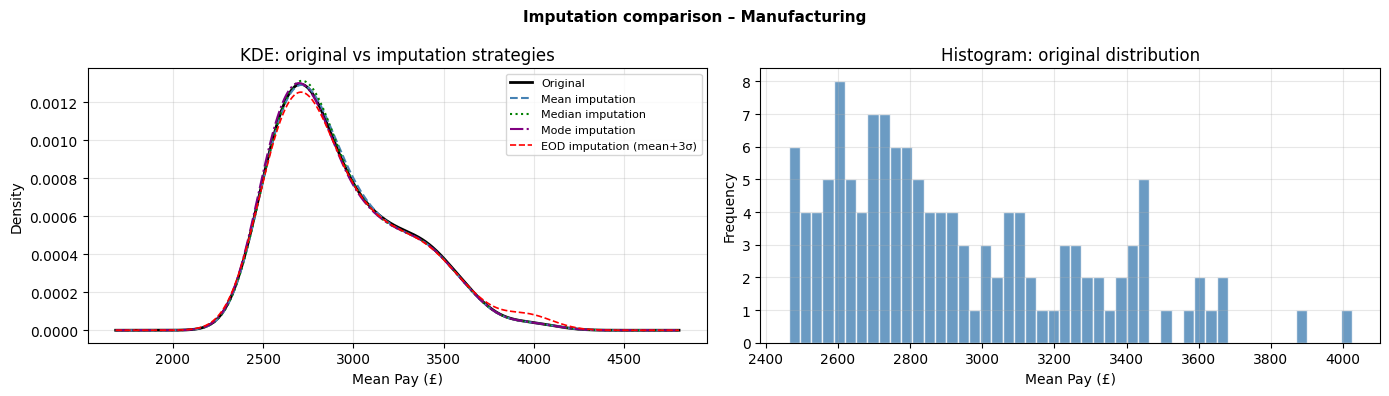


───────────────────────────────────────────────────────
Column : Mining and quarrying
  Mean   : 5685.05
  Median : 5454.00
  EOD    : 8004.00  (mean + 3×std)
  Missing: 1


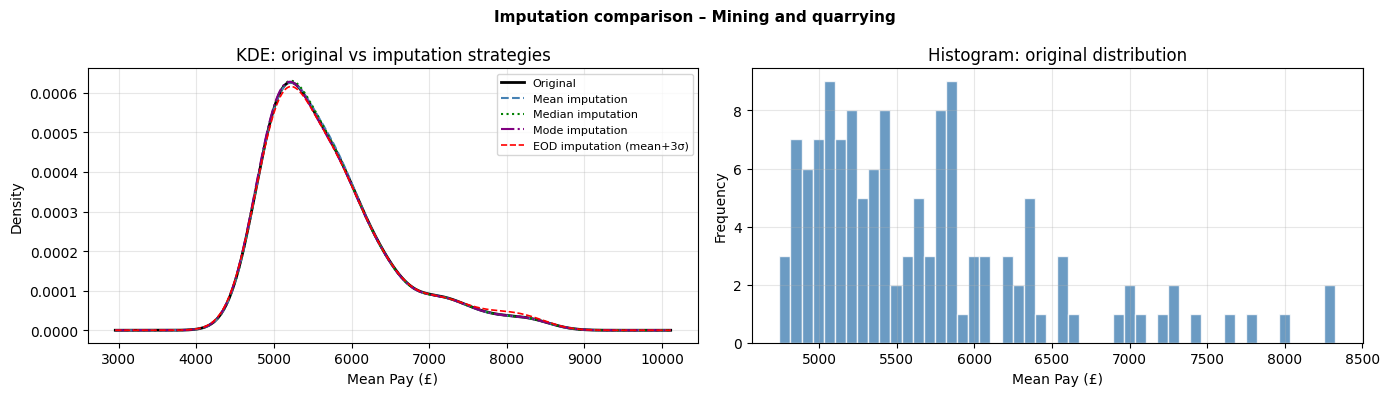


───────────────────────────────────────────────────────
Column : Other service activities
  Mean   : 1870.25
  Median : 1774.00
  EOD    : 2639.54  (mean + 3×std)
  Missing: 1


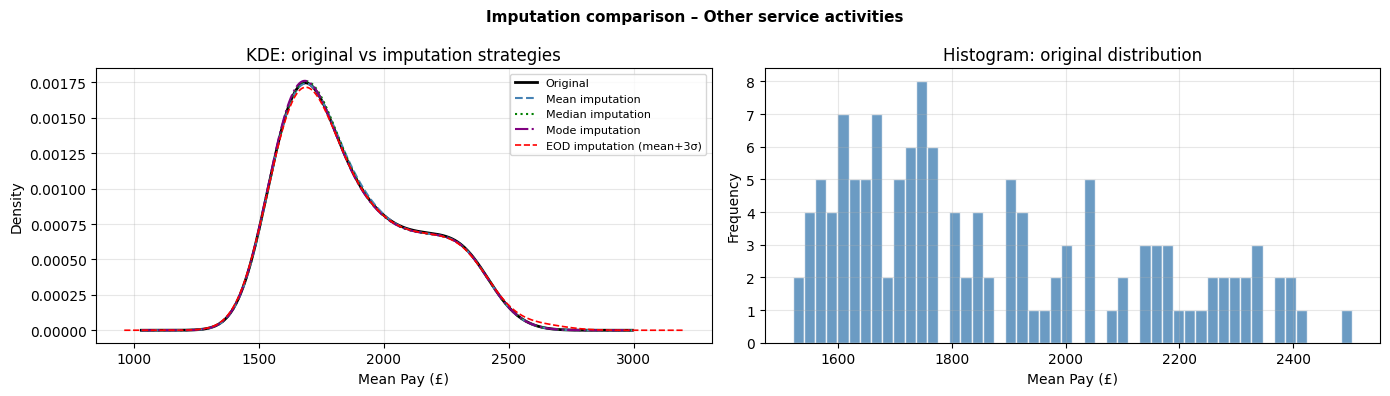


───────────────────────────────────────────────────────
Column : Water supply, sewerage and waste
  Mean   : 2864.73
  Median : 2776.00
  EOD    : 3869.18  (mean + 3×std)
  Missing: 4


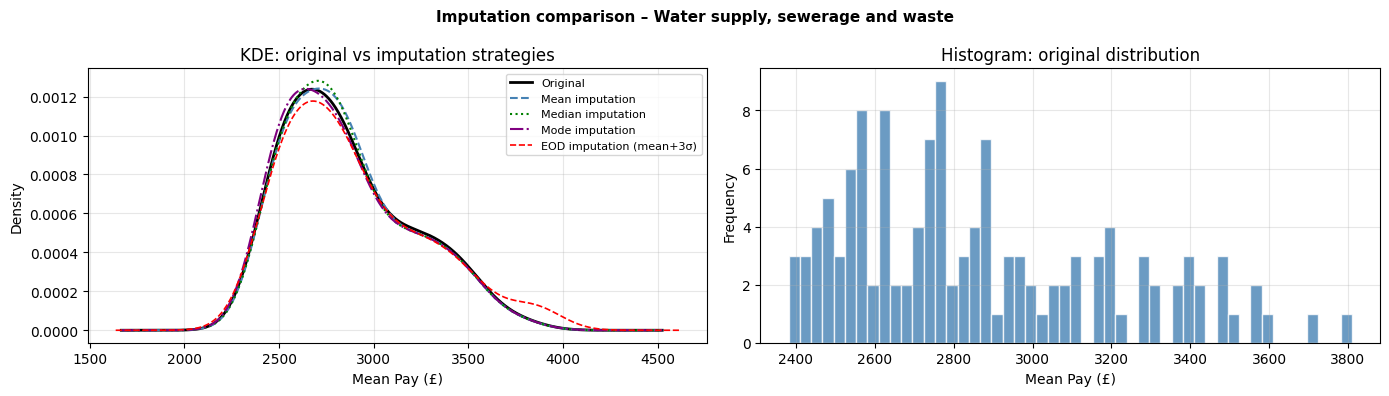

In [47]:
for col in cols_with_nan:

    median_val = mean_pay[col].median()
    mean_val   = mean_pay[col].mean()
    eod_value  = mean_pay[col].mean() + 3 * mean_pay[col].std()

    print(f"\n{'─'*55}")
    print(f"Column : {col}")
    print(f"  Mean   : {mean_val:.2f}")
    print(f"  Median : {median_val:.2f}")
    print(f"  EOD    : {eod_value:.2f}  (mean + 3×std)")
    print(f"  Missing: {mean_pay[col].isnull().sum()}")


    mean_pay[f'Mean_{col}']   = mean_pay[col].fillna(mean_val)
    mean_pay[f'Median_{col}'] = mean_pay[col].fillna(median_val)
    mean_pay[f'Mode_{col}']   = mean_pay[col].fillna(mean_pay[col].mode()[0])
    mean_pay[f'eod_{col}']    = mean_pay[col].fillna(eod_value)


    mean_pay[f'Mean_{col}'] = np.round(mean_pay[f'Mean_{col}'], 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Imputation comparison – {col}',
                 fontsize=11, fontweight='bold')

    ax = axes[0]
    mean_pay[col].plot.kde(ax=ax, color='black',
                           linewidth=2, label='Original')
    mean_pay[f'Mean_{col}'].plot.kde(ax=ax, color='steelblue',
                                     linestyle='--', label='Mean imputation')
    mean_pay[f'Median_{col}'].plot.kde(ax=ax, color='green',
                                       linestyle=':',  label='Median imputation')
    mean_pay[f'Mode_{col}'].plot.kde(ax=ax, color='purple',
                                     linestyle='-.', label='Mode imputation')
    mean_pay[f'eod_{col}'].plot.kde(ax=ax, color='red',
                                    linestyle='--', linewidth=1.2,
                                    label='EOD imputation (mean+3σ)')
    ax.set_title('KDE: original vs imputation strategies')
    ax.set_xlabel('Mean Pay (£)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)




    mean_pay[col].hist(bins=50, ax=axes[1], color='steelblue',
                       edgecolor='white', alpha=0.8)
    axes[1].set_title('Histogram: original distribution')
    axes[1].set_xlabel('Mean Pay (£)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [48]:
mean_pay_clean = mean_pay.copy()
for col in cols_with_nan:
    mean_pay_clean[col] = mean_pay_clean[col].fillna(mean_pay_clean[col].mean())

print("\nMissing values after mean imputation:")
print(mean_pay_clean[cols_with_nan].isnull().sum())


Missing values after mean imputation:
Accommodation and food service activities    0
Agriculture, forestry and fishing            0
Energy production and supply                 0
Households and Extraterritorial              0
Information and communication                0
Manufacturing                                0
Mining and quarrying                         0
Other service activities                     0
Water supply, sewerage and waste             0
dtype: int64


In [49]:
mean_pay_clean

,Date,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,...,Mode_Mining and quarrying,eod_Mining and quarrying,Mean_Other service activities,Median_Other service activities,Mode_Other service activities,eod_Other service activities,"Mean_Water supply, sewerage and waste","Median_Water supply, sewerage and waste","Mode_Water supply, sewerage and waste","eod_Water supply, sewerage and waste"
1970-01-01 00:00:00.000000000,2014-07-01,0.0,4969.0,2531.0,3584.0,2543.000000,2392,1627,2450,1086.000000,...,4969.0,4969.0,1545.0,1545.0,1545.0,1545.0,2543.0,2543.0,2543.0,2543.000000
1970-01-01 00:00:00.000000001,2014-08-01,1581.0,4793.0,2463.0,3455.0,2381.000000,2373,1614,2415,1097.000000,...,4793.0,4793.0,1557.0,1557.0,1557.0,1557.0,2381.0,2381.0,2381.0,2381.000000
1970-01-01 00:00:00.000000002,2014-09-01,1595.0,4866.0,2470.0,3364.0,2394.000000,2399,1602,2395,1089.000000,...,4866.0,4866.0,1521.0,1521.0,1521.0,1521.0,2394.0,2394.0,2394.0,2394.000000
1970-01-01 00:00:00.000000003,2014-10-01,1566.0,4892.0,2477.0,3399.0,2400.000000,2398,1633,2407,1103.000000,...,4892.0,4892.0,1531.0,1531.0,1531.0,1531.0,2400.0,2400.0,2400.0,2400.000000
1970-01-01 00:00:00.000000004,2014-11-01,1549.0,4979.0,2925.0,3462.0,2426.000000,2436,1627,2440,1119.000000,...,4979.0,4979.0,1566.0,1566.0,1566.0,1566.0,2426.0,2426.0,2426.0,2426.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000000127,2025-02-01,2297.0,7223.0,3596.0,5616.0,2864.734375,3211,2496,3333,1326.736434,...,7223.0,7223.0,2345.0,2345.0,2345.0,2345.0,2864.7,2776.0,2488.0,3869.181254
1970-01-01 00:00:00.000000128,2025-03-01,2429.0,8322.0,4024.0,6576.0,3570.000000,3407,2949,3526,1738.000000,...,8322.0,8322.0,2503.0,2503.0,2503.0,2503.0,3570.0,3570.0,3570.0,3570.000000
1970-01-01 00:00:00.000000129,2025-04-01,2424.0,7660.0,3667.0,6027.0,3511.000000,3237,2569,3376,1718.000000,...,7660.0,7660.0,2387.0,2387.0,2387.0,2387.0,3511.0,3511.0,3511.0,3511.000000
1970-01-01 00:00:00.000000130,2025-05-01,2429.0,6041.0,3584.0,5524.0,3601.000000,3224,2562,3381,1755.000000,...,6041.0,6041.0,2393.0,2393.0,2393.0,2393.0,3601.0,3601.0,3601.0,3601.000000



**TECHNIQUE 2: Categorical Encoding – OrdinalEncoder**

The dataset contains categorical and temporal features that must be transformed into a numerical format for machine learning. Encoding categorical variables and structuring the data as a time series ensures compatibility with models while preserving information.

In [50]:
pip install category_encoders

In [51]:
import category_encoders as ce

flag_col   = 'Was there any payroll error or Data Issue this month'
region_col = ('Majority of the payroll were contributed by people '
              'from region North East, North West or East Midlands')

categorical_features3 = mean_pay_clean.select_dtypes(include=[object])
categorical_features3.columns

for col in categorical_features3:
    print(col)
    print(mean_pay_clean[col].value_counts())
    print("-" * 40)

Was there any payroll error or Data Issue this month
Was there any payroll error or Data Issue this month
no      57
yes     56
yes     19
Name: count, dtype: int64
----------------------------------------
Majority of the payroll were contributed by people from region North East, North West or East Midlands
Majority of the payroll were contributed by people from region North East, North West or East Midlands
North East       55
East Midlands    40
North West       37
Name: count, dtype: int64
----------------------------------------


In [52]:
mean_pay_clean[flag_col] = (mean_pay_clean[flag_col]
                            .fillna('Missing')
                            .astype(str)
                            .str.strip()
                            .str.capitalize())

mean_pay_clean[region_col] = (mean_pay_clean[region_col]
                               .fillna('Missing')
                               .astype(str)
                               .str.strip()
                               .str.capitalize())

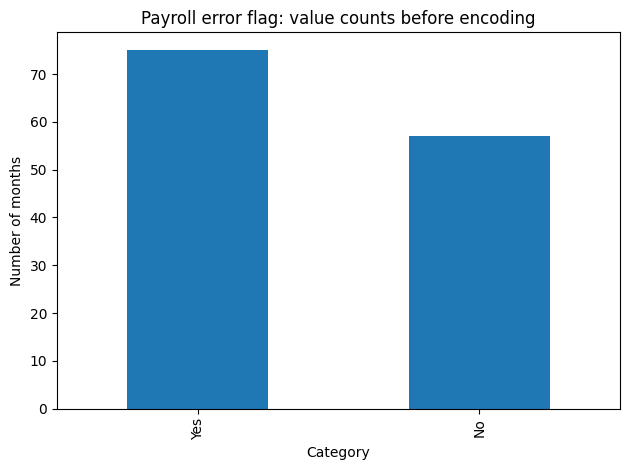

In [53]:
mean_pay_clean[flag_col].value_counts().plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Number of months')
plt.title('Payroll error flag: value counts before encoding')
plt.tight_layout()
plt.show()

In [54]:
encoder = ce.OrdinalEncoder(
    cols=[flag_col],
    return_df=True,
    mapping=[{'col': flag_col,
              'mapping': {'None': 0, 'No': 1, 'Yes': 2, 'Missing': 3}}])

In [55]:
print(mean_pay_clean[[flag_col]].head(10))

                              Was there any payroll error or Data Issue this month
1970-01-01 00:00:00.000000000                                                Yes  
1970-01-01 00:00:00.000000001                                                 No  
1970-01-01 00:00:00.000000002                                                Yes  
1970-01-01 00:00:00.000000003                                                 No  
1970-01-01 00:00:00.000000004                                                 No  
1970-01-01 00:00:00.000000005                                                Yes  
1970-01-01 00:00:00.000000006                                                Yes  
1970-01-01 00:00:00.000000007                                                Yes  
1970-01-01 00:00:00.000000008                                                 No  
1970-01-01 00:00:00.000000009                                                Yes  


In [56]:
mean_pay_clean = encoder.fit_transform(mean_pay_clean)

print("\nAfter encoding:")
print(mean_pay_clean[[flag_col]].head(10))


After encoding:
                               Was there any payroll error or Data Issue this month
1970-01-01 00:00:00.000000000                                                  2   
1970-01-01 00:00:00.000000001                                                  1   
1970-01-01 00:00:00.000000002                                                  2   
1970-01-01 00:00:00.000000003                                                  1   
1970-01-01 00:00:00.000000004                                                  1   
1970-01-01 00:00:00.000000005                                                  2   
1970-01-01 00:00:00.000000006                                                  2   
1970-01-01 00:00:00.000000007                                                  2   
1970-01-01 00:00:00.000000008                                                  1   
1970-01-01 00:00:00.000000009                                                  2   


2-yes, 1 -no

In [57]:
encoder = ce.OrdinalEncoder(
    cols=[region_col],
    return_df=True,
    mapping=[{'col': region_col,
              'mapping': {'None':          0,
                          'North east':    1,
                          'North west':    2,
                          'East midlands': 3,
                          'Missing':       4}}])

print(mean_pay_clean[[region_col]].head(10))

                              Majority of the payroll were contributed by people from region North East, North West or East Midlands
1970-01-01 00:00:00.000000000                                         North east                                                    
1970-01-01 00:00:00.000000001                                         North east                                                    
1970-01-01 00:00:00.000000002                                         North west                                                    
1970-01-01 00:00:00.000000003                                      East midlands                                                    
1970-01-01 00:00:00.000000004                                         North east                                                    
1970-01-01 00:00:00.000000005                                         North east                                                    
1970-01-01 00:00:00.000000006                                        

In [58]:

mean_pay_clean = encoder.fit_transform(mean_pay_clean)

print("\nAfter encoding:")
print(mean_pay_clean[[region_col]].head(10))



After encoding:
                               Majority of the payroll were contributed by people from region North East, North West or East Midlands
1970-01-01 00:00:00.000000000                                                  1                                                     
1970-01-01 00:00:00.000000001                                                  1                                                     
1970-01-01 00:00:00.000000002                                                  2                                                     
1970-01-01 00:00:00.000000003                                                  3                                                     
1970-01-01 00:00:00.000000004                                                  1                                                     
1970-01-01 00:00:00.000000005                                                  1                                                     
1970-01-01 00:00:00.000000006                

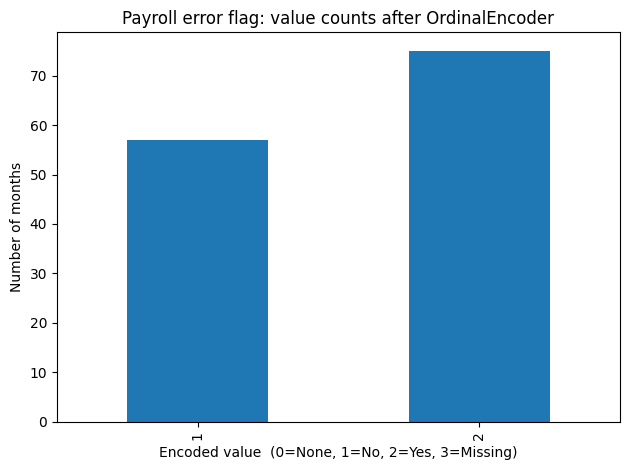

In [59]:
mean_pay_clean[flag_col].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Encoded value  (0=None, 1=No, 2=Yes, 3=Missing)')
plt.ylabel('Number of months')
plt.title('Payroll error flag: value counts after OrdinalEncoder')
plt.tight_layout()
plt.show()

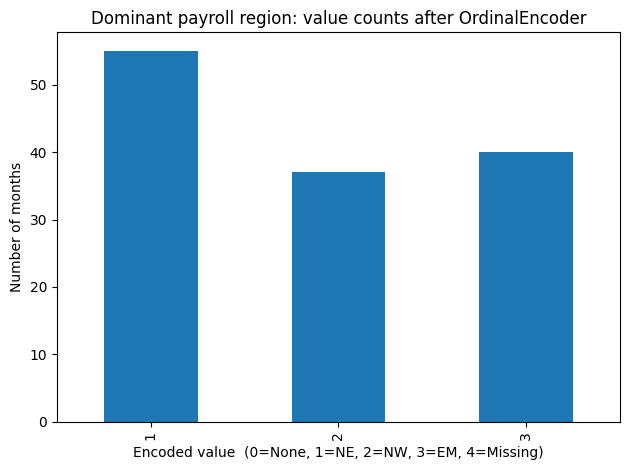

In [60]:
mean_pay_clean[region_col].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Encoded value  (0=None, 1=NE, 2=NW, 3=EM, 4=Missing)')
plt.ylabel('Number of months')
plt.title('Dominant payroll region: value counts after OrdinalEncoder')
plt.tight_layout()
plt.show()

In [61]:
categorical_features3 = mean_pay_clean.select_dtypes(include=[object])
print("Remained object-columns:", categorical_features3.columns.tolist())

Remained object-columns: []


In [62]:
mean_pay_clean

,Date,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,...,Mode_Mining and quarrying,eod_Mining and quarrying,Mean_Other service activities,Median_Other service activities,Mode_Other service activities,eod_Other service activities,"Mean_Water supply, sewerage and waste","Median_Water supply, sewerage and waste","Mode_Water supply, sewerage and waste","eod_Water supply, sewerage and waste"
1970-01-01 00:00:00.000000000,2014-07-01,0.0,4969.0,2531.0,3584.0,2543.000000,2392,1627,2450,1086.000000,...,4969.0,4969.0,1545.0,1545.0,1545.0,1545.0,2543.0,2543.0,2543.0,2543.000000
1970-01-01 00:00:00.000000001,2014-08-01,1581.0,4793.0,2463.0,3455.0,2381.000000,2373,1614,2415,1097.000000,...,4793.0,4793.0,1557.0,1557.0,1557.0,1557.0,2381.0,2381.0,2381.0,2381.000000
1970-01-01 00:00:00.000000002,2014-09-01,1595.0,4866.0,2470.0,3364.0,2394.000000,2399,1602,2395,1089.000000,...,4866.0,4866.0,1521.0,1521.0,1521.0,1521.0,2394.0,2394.0,2394.0,2394.000000
1970-01-01 00:00:00.000000003,2014-10-01,1566.0,4892.0,2477.0,3399.0,2400.000000,2398,1633,2407,1103.000000,...,4892.0,4892.0,1531.0,1531.0,1531.0,1531.0,2400.0,2400.0,2400.0,2400.000000
1970-01-01 00:00:00.000000004,2014-11-01,1549.0,4979.0,2925.0,3462.0,2426.000000,2436,1627,2440,1119.000000,...,4979.0,4979.0,1566.0,1566.0,1566.0,1566.0,2426.0,2426.0,2426.0,2426.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000000127,2025-02-01,2297.0,7223.0,3596.0,5616.0,2864.734375,3211,2496,3333,1326.736434,...,7223.0,7223.0,2345.0,2345.0,2345.0,2345.0,2864.7,2776.0,2488.0,3869.181254
1970-01-01 00:00:00.000000128,2025-03-01,2429.0,8322.0,4024.0,6576.0,3570.000000,3407,2949,3526,1738.000000,...,8322.0,8322.0,2503.0,2503.0,2503.0,2503.0,3570.0,3570.0,3570.0,3570.000000
1970-01-01 00:00:00.000000129,2025-04-01,2424.0,7660.0,3667.0,6027.0,3511.000000,3237,2569,3376,1718.000000,...,7660.0,7660.0,2387.0,2387.0,2387.0,2387.0,3511.0,3511.0,3511.0,3511.000000
1970-01-01 00:00:00.000000130,2025-05-01,2429.0,6041.0,3584.0,5524.0,3601.000000,3224,2562,3381,1755.000000,...,6041.0,6041.0,2393.0,2393.0,2393.0,2393.0,3601.0,3601.0,3601.0,3601.000000


Standard Scaler

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import FunctionTransformer

In [64]:
employees_uk_series = employees['UK'].iloc[:50].reset_index(drop=True)
mean_pay_uk_series  = mean_pay_clean['UK'].iloc[:50].reset_index(drop=True)

cluster_df = pd.DataFrame({'Employees': pd.to_numeric(employees_uk_series, errors='coerce'),'PAYE':pd.to_numeric(mean_pay_uk_series, errors='coerce')}).dropna()
cluster_df.describe()

,Employees,PAYE
count,5.000000e+01,50.000000
mean,2.788311e+07,2285.940000
std,5.424533e+05,108.747303
min,2.686540e+07,2133.000000
25%,2.759474e+07,2213.000000
50%,2.797341e+07,2266.500000
75%,2.835178e+07,2362.000000
max,2.876055e+07,2624.000000


In [65]:
sc = StandardScaler()

x_new = cluster_df.copy()
print(cluster_df)

x_new[['Employees', 'PAYE']] = sc.fit_transform(x_new[['Employees', 'PAYE']])
print(x_new)
print(cluster_df)

    Employees  PAYE
0    26893849  2151
1    26865396  2141
2    26945380  2134
3    26965178  2133
4    27159526  2159
5    27036320  2256
6    27008211  2243
7    27044403  2345
8    27168394  2432
9    27256231  2213
10   27374760  2190
11   27545083  2207
12   27654597  2190
13   27589501  2172
14   27667062  2160
15   27732200  2164
16   27879548  2181
17   27723593  2257
18   27610449  2241
19   27625227  2350
20   27686085  2463
21   27741911  2249
22   27850628  2232
23   27996784  2253
24   28088112  2234
25   27987478  2213
26   28042745  2222
27   28077222  2225
28   28213802  2236
29   28121565  2311
30   27937656  2295
31   27959346  2420
32   28048657  2540
33   28114924  2302
34   28224454  2300
35   28364254  2315
36   28439059  2285
37   28371880  2276
38   28427372  2280
39   28465998  2278
40   28599938  2294
41   28503401  2380
42   28329746  2376
43   28322029  2504
44   28359126  2624
45   28462802  2366
46   28544721  2368
47   28667756  2401
48   28760549  2368


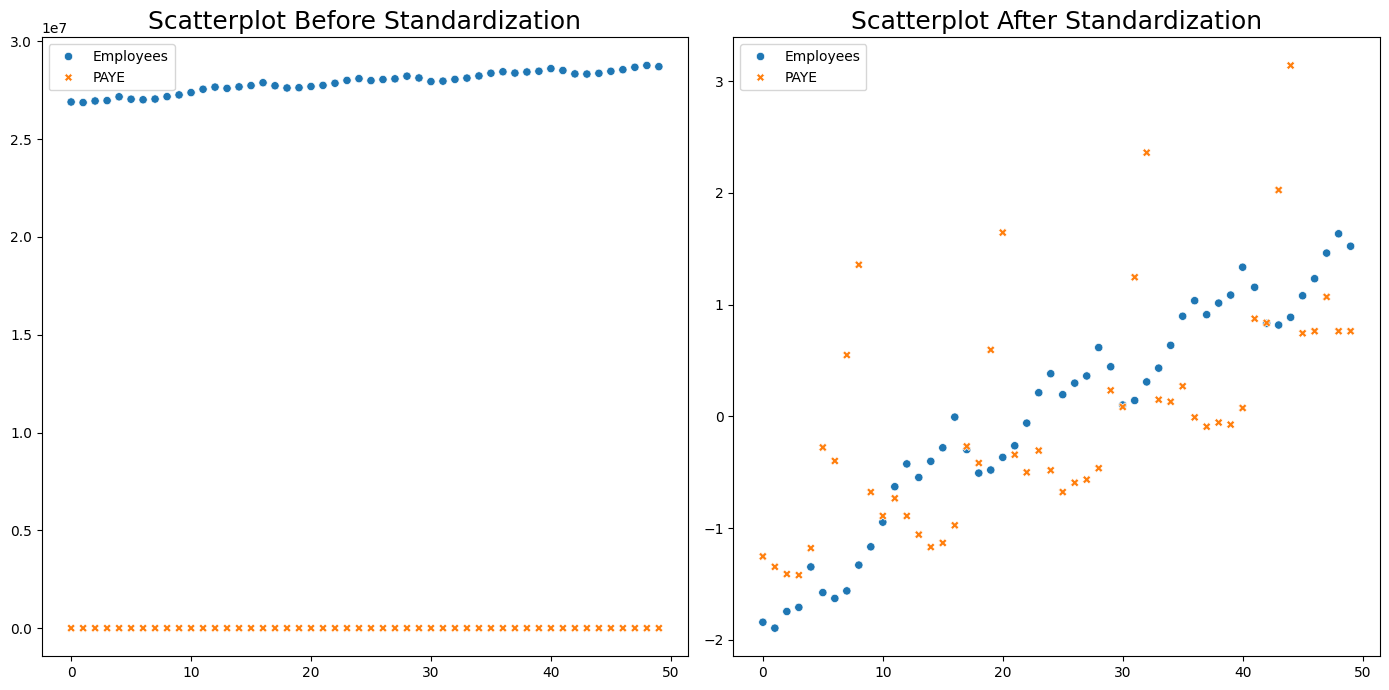

In [66]:
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.title("Scatterplot Before Standardization", fontsize=18)
sns.scatterplot(data=cluster_df, color="blue")
plt.subplot(1, 2, 2)
plt.title("Scatterplot After Standardization", fontsize=18)
sns.scatterplot(data=x_new, color="red")
plt.tight_layout()
plt.show()

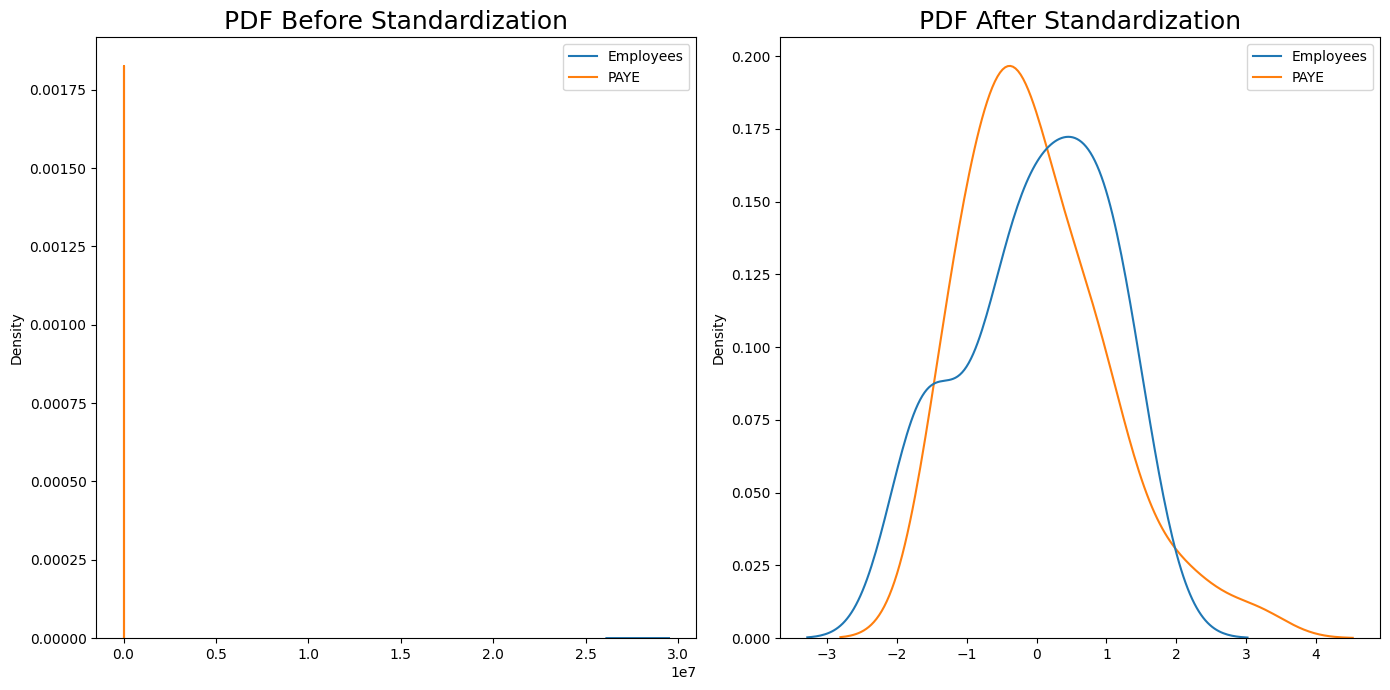

In [67]:
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.title("PDF Before Standardization", fontsize=18)
sns.kdeplot(data=cluster_df, color="blue")
plt.subplot(1, 2, 2)
plt.title("PDF After Standardization", fontsize=18)
sns.kdeplot(data=x_new, color="red")
plt.tight_layout()
plt.show()

In [68]:
sc1 = MinMaxScaler()

x_new1 = cluster_df.copy()
x_new1[['Employees', 'PAYE']] = sc1.fit_transform(x_new1[['Employees', 'PAYE']])
print(x_new1)
print(x_new)
print(cluster_df)

    Employees      PAYE
0    0.015014  0.036660
1    0.000000  0.016293
2    0.042205  0.002037
3    0.052651  0.000000
4    0.155201  0.052953
5    0.090190  0.250509
6    0.075358  0.224033
7    0.094455  0.431772
8    0.159880  0.608961
9    0.206229  0.162933
10   0.268772  0.116090
11   0.358645  0.150713
12   0.416431  0.116090
13   0.382083  0.079430
14   0.423009  0.054990
15   0.457379  0.063136
16   0.535129  0.097760
17   0.452838  0.252546
18   0.393136  0.219959
19   0.400934  0.441955
20   0.433046  0.672098
21   0.462504  0.236253
22   0.519869  0.201629
23   0.596990  0.244399
24   0.645181  0.205703
25   0.592080  0.162933
26   0.621242  0.181263
27   0.639434  0.187373
28   0.711502  0.209776
29   0.662832  0.362525
30   0.565791  0.329939
31   0.577236  0.584521
32   0.624362  0.828921
33   0.659328  0.344196
34   0.717123  0.340122
35   0.790890  0.370672
36   0.830362  0.309572
37   0.794914  0.291242
38   0.824195  0.299389
39   0.844577  0.295316
40   0.915252  0

In [69]:
transformer = FunctionTransformer(np.log1p)

x_new_log = cluster_df.copy()
x_new_log[['Employees', 'PAYE']] = transformer.fit_transform(
    x_new_log[['Employees', 'PAYE']])
print(x_new_log)

    Employees      PAYE
0   17.107408  7.674153
1   17.106350  7.669495
2   17.109322  7.666222
3   17.110057  7.665753
4   17.117238  7.677864
5   17.112692  7.721792
6   17.111652  7.716015
7   17.112991  7.760467
8   17.117565  7.796880
9   17.120793  7.702556
10  17.125132  7.692113
11  17.131335  7.699842
12  17.135303  7.692113
13  17.132946  7.683864
14  17.135753  7.678326
15  17.138105  7.680176
16  17.143404  7.687997
17  17.137794  7.722235
18  17.133705  7.715124
19  17.134240  7.762596
20  17.136441  7.809541
21  17.138455  7.718685
22  17.142366  7.711101
23  17.147600  7.720462
24  17.150857  7.711997
25  17.147268  7.702556
26  17.149241  7.706613
27  17.150469  7.707962
28  17.155322  7.712891
29  17.152047  7.745868
30  17.145486  7.738924
31  17.146262  7.791936
32  17.149451  7.840313
33  17.151811  7.741968
34  17.155699  7.741099
35  17.160640  7.747597
36  17.163274  7.734559
37  17.160909  7.730614
38  17.162863  7.732369
39  17.164221  7.731492
40  17.168915  7

In [70]:
sc2 = MaxAbsScaler()

x_new2 = cluster_df.copy()
x_new2[['Employees', 'PAYE']] = sc2.fit_transform(x_new2[['Employees', 'PAYE']])
print(x_new2)
print('\n')
print(x_new1)
print('\n')
print(cluster_df)

    Employees      PAYE
0    0.935095  0.819741
1    0.934106  0.815930
2    0.936887  0.813262
3    0.937575  0.812881
4    0.944333  0.822790
5    0.940049  0.859756
6    0.939071  0.854802
7    0.940330  0.893674
8    0.944641  0.926829
9    0.947695  0.843369
10   0.951816  0.834604
11   0.957738  0.841082
12   0.961546  0.834604
13   0.959283  0.827744
14   0.961980  0.823171
15   0.964244  0.824695
16   0.969368  0.831174
17   0.963945  0.860137
18   0.960011  0.854040
19   0.960525  0.895579
20   0.962641  0.938643
21   0.964582  0.857088
22   0.968362  0.850610
23   0.973444  0.858613
24   0.976619  0.851372
25   0.973120  0.843369
26   0.975042  0.846799
27   0.976241  0.847942
28   0.980990  0.852134
29   0.977783  0.880716
30   0.971388  0.874619
31   0.972142  0.922256
32   0.975248  0.967988
33   0.977552  0.877287
34   0.981360  0.876524
35   0.986221  0.882241
36   0.988822  0.870808
37   0.986486  0.867378
38   0.988415  0.868902
39   0.989759  0.868140
40   0.994416  0

In [71]:
sc3 = RobustScaler()

x_new3 = cluster_df.copy()
x_new3[['Employees', 'PAYE']] = sc3.fit_transform(x_new3[['Employees', 'PAYE']])
print(x_new3)
print('\n')
print(x_new2)
print('\n')
print(cluster_df)

    Employees      PAYE
0   -1.426026 -0.775168
1   -1.463610 -0.842282
2   -1.357957 -0.889262
3   -1.331805 -0.895973
4   -1.075086 -0.721477
5   -1.237832 -0.070470
6   -1.274962 -0.157718
7   -1.227155  0.526846
8   -1.063372  1.110738
9   -0.947345 -0.359060
10  -0.790777 -0.513423
11  -0.565792 -0.399329
12  -0.421132 -0.513423
13  -0.507119 -0.634228
14  -0.404667 -0.714765
15  -0.318624 -0.687919
16  -0.123988 -0.573826
17  -0.329993 -0.063758
18  -0.479448 -0.171141
19  -0.459928  0.560403
20  -0.379539  1.318792
21  -0.305796 -0.117450
22  -0.162189 -0.231544
23   0.030873 -0.090604
24   0.151511 -0.218121
25   0.018580 -0.359060
26   0.091584 -0.298658
27   0.137126 -0.278523
28   0.317538 -0.204698
29   0.195700  0.298658
30  -0.047231  0.191275
31  -0.018580  1.030201
32   0.099393  1.835570
33   0.186927  0.238255
34   0.331609  0.224832
35   0.516275  0.325503
36   0.615087  0.124161
37   0.526348  0.063758
38   0.599649  0.090604
39   0.650671  0.077181
40   0.827596  0

In [72]:
print("Before scaling:")
print(cluster_df.describe())

scaledcluster = x_new.copy()
print('\nAfter scaling (StandardScaler):')
print(scaledcluster.describe())

Before scaling:
          Employees         PAYE
count  5.000000e+01    50.000000
mean   2.788311e+07  2285.940000
std    5.424533e+05   108.747303
min    2.686540e+07  2133.000000
25%    2.759474e+07  2213.000000
50%    2.797341e+07  2266.500000
75%    2.835178e+07  2362.000000
max    2.876055e+07  2624.000000

After scaling (StandardScaler):
          Employees          PAYE
count  5.000000e+01  5.000000e+01
mean   8.260059e-16 -4.973799e-16
std    1.010153e+00  1.010153e+00
min   -1.895183e+00 -1.420658e+00
25%   -5.370080e-01 -6.775389e-01
50%    1.681560e-01 -1.805780e-01
75%    8.727519e-01  7.065205e-01
max    1.633957e+00  3.140236e+00


------------------

----------------

##**Task 4: Supervised ML algorithm**

In [73]:
dataset = pd.read_excel('Mean Pay (Industry).xlsx')
dataset = dataset.drop(columns=[dataset.columns[1], dataset.columns[2]])
dataset = dataset.rename(columns={dataset.columns[0]: 'Date'})
dataset = dataset.set_index('Date')
dataset = dataset.T
dataset = dataset.apply(pd.to_numeric, errors='coerce')
print(dataset.shape)
dataset.head()

(21, 132)


Date,July 2014,August 2014,September 2014,October 2014,November 2014,December 2014,January 2015,February 2015,March 2015,April 2015,...,September 2024,October 2024,November 2024,December 2024,January 2025,February 2025,March 2025,April 2025,May 2025,June 2025
Manufacturing,2531.0,2463.0,2470.0,2477.0,NaN,2706.0,2509.0,2603.0,2786.0,2555.0,...,3380.0,3396.0,3450.0,3662.0,3424.0,3596.0,4024.0,3667.0,3584.0,3602.0
Energy production and supply,3584.0,3455.0,3364.0,3399.0,3462.0,3439.0,3553.0,3945.0,4329.0,3799.0,...,4849.0,4990.0,5027.0,5122.0,5257.0,5616.0,6576.0,6027.0,5524.0,5821.0
"Water supply, sewerage and waste",2543.0,2381.0,2394.0,2400.0,2426.0,2488.0,2438.0,2443.0,2570.0,2550.0,...,3363.0,3384.0,3389.0,3478.0,3417.0,NaN,3570.0,3511.0,3601.0,3810.0
Construction,2392.0,2373.0,2399.0,2398.0,2436.0,2570.0,2360.0,2409.0,2558.0,2391.0,...,3153.0,3152.0,3202.0,3361.0,3128.0,3211.0,3407.0,3237.0,3224.0,3246.0
Wholesale and retail; repair of motor vehicles,1627.0,1614.0,1602.0,1633.0,1627.0,1661.0,1629.0,1661.0,1833.0,1711.0,...,2382.0,2404.0,2428.0,2471.0,2393.0,2496.0,2949.0,2569.0,2562.0,2537.0


In [74]:
dataset.columns = pd.to_datetime(dataset.columns, format='%B %Y')
dataset = dataset.sort_index(axis=1)

In [75]:
target_month     = pd.Timestamp('2025-06-01')
all_feature_cols = [col for col in dataset.columns if col != target_month]
feature_cols     = all_feature_cols[-12:]


print("Target column (y):", target_month)
print("Feature columns (X):", [str(c.strftime('%B %Y')) for c in feature_cols])

Target column (y): 2025-06-01 00:00:00
Feature columns (X): ['June 2024', 'July 2024', 'August 2024', 'September 2024', 'October 2024', 'November 2024', 'December 2024', 'January 2025', 'February 2025', 'March 2025', 'April 2025', 'May 2025']


In [76]:
X = dataset[feature_cols].values
y = dataset[target_month].values

In [77]:
mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
X = X[mask]
y = y[mask]

print(X)
print(y)

[[ 3461.  3412.  3359.  3380.  3396.  3450.  3662.  3424.  3596.  4024.
   3667.  3584.]
 [ 5429.  5101.  4906.  4849.  4990.  5027.  5122.  5257.  5616.  6576.
   6027.  5524.]
 [ 3127.  3105.  3088.  3153.  3152.  3202.  3361.  3128.  3211.  3407.
   3237.  3224.]
 [ 2444.  2421.  2374.  2382.  2404.  2428.  2471.  2393.  2496.  2949.
   2569.  2562.]
 [ 3320.  3282.  3222.  3255.  3373.  3360.  3408.  3250.  3333.  3526.
   3376.  3381.]
 [ 5455.  5276.  5191.  5199.  5251.  5203.  5618.  5572.  5890.  6338.
   5329.  5491.]
 [ 6685.  6179.  6321.  6162.  6078.  6291.  7451.  9390. 11750. 11981.
   7040.  7097.]
 [ 3137.  3132.  2994.  3011.  3020.  3055.  3222.  3065.  3146.  3583.
   3171.  3145.]
 [ 4634.  4466.  4428.  4385.  4399.  4552.  4796.  4589.  5085.  5634.
   4616.  4632.]
 [ 2804.  2803.  2824.  2807.  2855.  2816.  2938.  2970.  3140.  3366.
   2971.  2898.]
 [ 3211.  3192.  3239.  3330.  3364.  3612.  3389.  3349.  3331.  3338.
   3350.  3374.]
 [ 2696.  2696.  2710

In [78]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [79]:
print(X_train)
print(y_train)
print(X_test)
print(y_test)

[[2774. 2715. 2672. 2821. 2555. 2585. 2681. 2638. 2685. 2765. 2673. 2655.]
 [3320. 3282. 3222. 3255. 3373. 3360. 3408. 3250. 3333. 3526. 3376. 3381.]
 [3127. 3105. 3088. 3153. 3152. 3202. 3361. 3128. 3211. 3407. 3237. 3224.]
 [2305. 2308. 2294. 2308. 2285. 2328. 2381. 2330. 2345. 2503. 2387. 2393.]
 [3211. 3192. 3239. 3330. 3364. 3612. 3389. 3349. 3331. 3338. 3350. 3374.]
 [3137. 3132. 2994. 3011. 3020. 3055. 3222. 3065. 3146. 3583. 3171. 3145.]
 [3176. 3117. 3106. 3118. 3183. 3223. 3315. 3307. 3510. 3739. 3287. 3280.]
 [2696. 2696. 2710. 2722. 2780. 2941. 2858. 2753. 2758. 2765. 2782. 2783.]
 [2444. 2421. 2374. 2382. 2404. 2428. 2471. 2393. 2496. 2949. 2569. 2562.]
 [3461. 3412. 3359. 3380. 3396. 3450. 3662. 3424. 3596. 4024. 3667. 3584.]
 [5455. 5276. 5191. 5199. 5251. 5203. 5618. 5572. 5890. 6338. 5329. 5491.]
 [1620. 1619. 1640. 1623. 1625. 1644. 1691. 1647. 1632. 1665. 1684. 1695.]
 [2811. 2774. 2791. 2837. 3153. 3038. 2905. 2906. 2917. 2930. 2943. 2926.]]
[2894. 3386. 3246. 2406.

Linear Regression model

In [80]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [81]:
regressor.intercept_

np.float64(-148.0537900992049)

In [82]:
regressor.coef_

array([ 1.37697413, -1.90326274,  2.20519177, -0.13359262,  0.0664723 ,
       -0.32635661, -0.06836002,  0.92888981, -1.07458558,  0.40465266,
        0.24679033, -0.60728346])

In [83]:
y_pred = regressor.predict(X_test)

In [84]:
y_pred

array([5772.90626421, 6625.68737832, 4795.10804925, 3020.49119934])

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 151.00140151614755
MSE: 29870.070925469037
RMSE: 172.82960083697768
R2 Score: 0.9864924442909331


In [86]:
y_test

array([5821., 6907., 4645., 2896.])

In [87]:
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred), 1),y_test.reshape(len(y_test), 1)), 1))

[[5772.91 5821.  ]
 [6625.69 6907.  ]
 [4795.11 4645.  ]
 [3020.49 2896.  ]]


In [88]:
y_train_pred = regressor.predict(X_train)

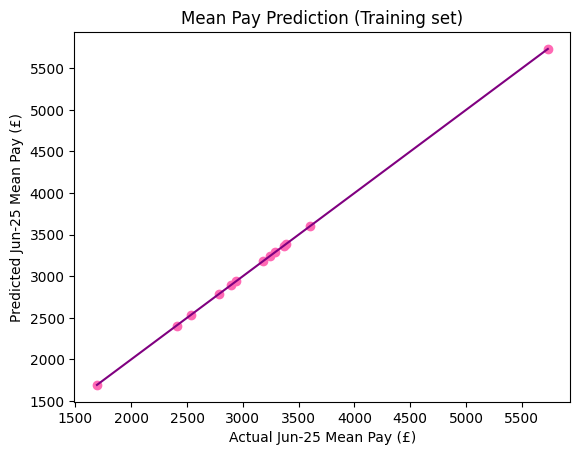

In [89]:
plt.scatter(y_train, y_train_pred, color='hotpink')
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='purple')
plt.title('Mean Pay Prediction (Training set)')
plt.xlabel('Actual Jun-25 Mean Pay (£)')
plt.ylabel('Predicted Jun-25 Mean Pay (£)')
plt.show()

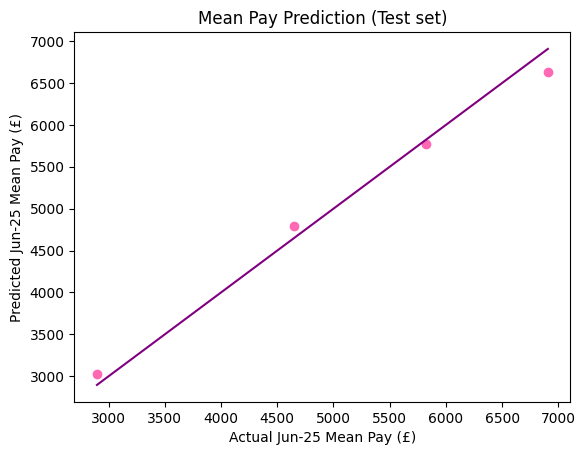

In [90]:
plt.scatter(y_test, y_pred, color='hotpink')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='purple')
plt.title('Mean Pay Prediction (Test set)')
plt.xlabel('Actual Jun-25 Mean Pay (£)')
plt.ylabel('Predicted Jun-25 Mean Pay (£)')
plt.show()

In [91]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

mse = mean_squared_error(y_test, y_pred)
print("MSE --> ", mse)

rmse = math.sqrt(mse)
print("RMSE --> ", rmse)

mae = mean_absolute_error(y_test, y_pred)
print("MAE --> ", mae)


r2 = r2_score(y_test, y_pred)
print("R2 --> ", r2)

print("MSE --> ",  mse)
print("RMSE --> ", rmse)
print("MAE --> ",  mae)
print("R2 --> ",   r2)

MSE -->  29870.070925469037
RMSE -->  172.82960083697768
MAE -->  151.00140151614755
R2 -->  0.9864924442909331
MSE -->  29870.070925469037
RMSE -->  172.82960083697768
MAE -->  151.00140151614755
R2 -->  0.9864924442909331


In [92]:
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred), 1),
                       y_test.reshape(len(y_test), 1)), 1))

[[5772.91 5821.  ]
 [6625.69 6907.  ]
 [4795.11 4645.  ]
 [3020.49 2896.  ]]


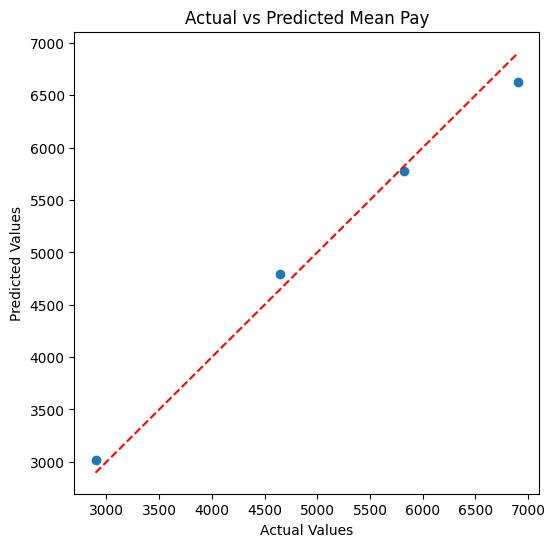

In [93]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Mean Pay")

plt.show()

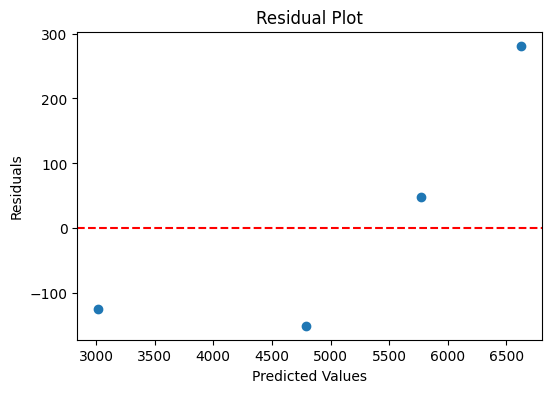

In [94]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Random forest regressor model

In [95]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=10, random_state=0)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, random_state=0)

In [96]:
rf_pred = rf.predict(X_test)

print(np.concatenate((rf_pred.reshape(len(rf_pred), 1),
                       y_test.reshape(len(y_test), 1)), 1))


[[4859. 5821.]
 [4859. 6907.]
 [4859. 4645.]
 [2985. 2896.]]


In [97]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

mse_rf  = mean_squared_error(y_test, rf_pred)
print("MSE --> ", mse_rf)

rmse_rf = math.sqrt(mse_rf)
print("RMSE --> ", rmse_rf)

mae_rf  = mean_absolute_error(y_test, rf_pred)
print("MAE --> ", mae_rf)

r2_rf   = r2_score(y_test, rf_pred)
print("R2 --> ", r2_rf)

print("MSE --> ",  mse_rf)
print("RMSE --> ", rmse_rf)
print("MAE --> ",  mae_rf)
print("R2 --> ",   r2_rf)

MSE -->  1293366.25
RMSE -->  1137.262612592184
MAE -->  828.25
R2 -->  0.4151263745675986
MSE -->  1293366.25
RMSE -->  1137.262612592184
MAE -->  828.25
R2 -->  0.4151263745675986


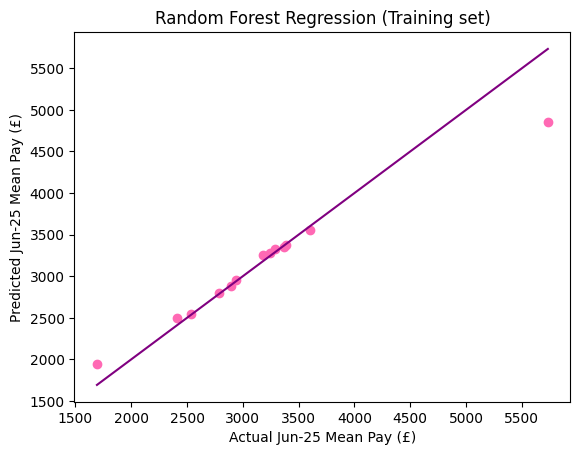

In [98]:
y_train_pred_rf = rf.predict(X_train)

plt.scatter(y_train, y_train_pred_rf, color='hotpink')
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='purple')
plt.title('Random Forest Regression (Training set)')
plt.xlabel('Actual Jun-25 Mean Pay (£)')
plt.ylabel('Predicted Jun-25 Mean Pay (£)')
plt.show()

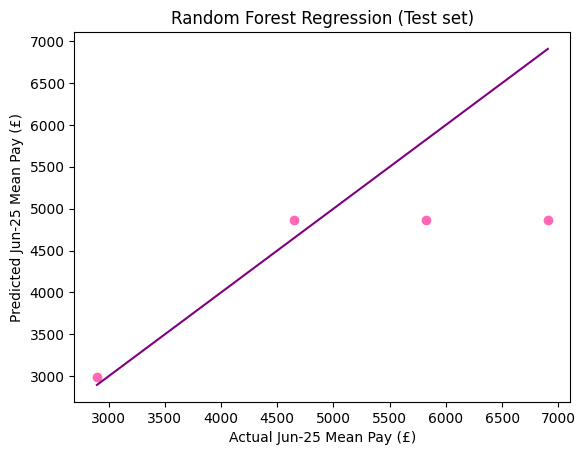

In [99]:
plt.scatter(y_test, rf_pred, color='hotpink')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='purple')
plt.title('Random Forest Regression (Test set)')
plt.xlabel('Actual Jun-25 Mean Pay (£)')
plt.ylabel('Predicted Jun-25 Mean Pay (£)')
plt.show()

In [100]:
print("Model Comparison:")
print(f"{'Metric':<8} {'Linear Regression':>20} {'Random Forest':>15}")
print("-" * 45)
print(f"{'MSE':<8} {mse:>20.2f} {mse_rf:>15.2f}")
print(f"{'RMSE':<8} {rmse:>20.2f} {rmse_rf:>15.2f}")
print(f"{'MAE':<8} {mae:>20.2f} {mae_rf:>15.2f}")
print(f"{'R2':<8} {r2:>20.4f} {r2_rf:>15.4f}")


Model Comparison:
Metric      Linear Regression   Random Forest
---------------------------------------------
MSE                  29870.07      1293366.25
RMSE                   172.83         1137.26
MAE                    151.00          828.25
R2                     0.9865          0.4151


In [101]:
results_rf = pd.DataFrame({
    "Actual_Jun25": y_test,
    "Predicted_Jun25": rf_pred
})

print("\nDetailed Results:")
print(results_rf)


Detailed Results:
   Actual_Jun25  Predicted_Jun25
0        5821.0           4859.0
1        6907.0           4859.0
2        4645.0           4859.0
3        2896.0           2985.0


In [102]:
print("\nSummary:")
print(f"Average prediction error (MAE): {mae_rf:.2f} £")
print(f"Model explains {r2_rf*100:.2f}% of variance in mean pay")


Summary:
Average prediction error (MAE): 828.25 £
Model explains 41.51% of variance in mean pay


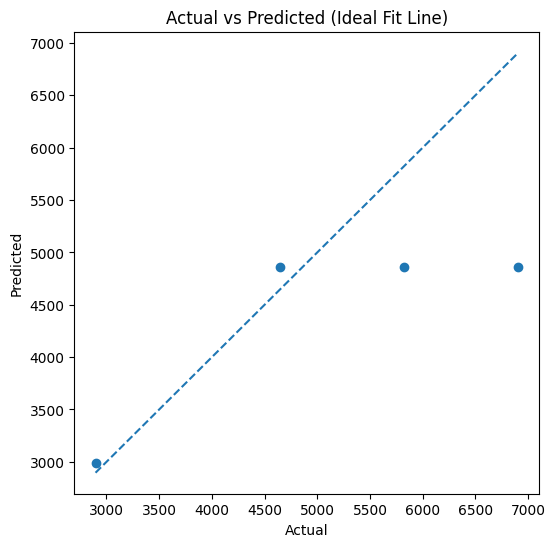

In [103]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         linestyle='--')
plt.title("Actual vs Predicted (Ideal Fit Line)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

----------------------

------------------------------

##**Task 5:Unsupervised ML algorithm**

In [104]:
emp_raw = pd.read_excel('Employees (Industry).xlsx')
pay_raw = pd.read_excel('Mean Pay (Industry).xlsx')

In [105]:
emp_col_V = pd.to_numeric(emp_raw.iloc[:, 21], errors='coerce')
pay_col_X = pd.to_numeric(pay_raw.iloc[:, 21], errors='coerce')

In [106]:
paye_df = pd.DataFrame({'Employees': emp_col_V,'PAYE': pay_col_X}).dropna()

In [107]:
paye_df.to_csv('employees_paye.csv', index=False)
print("Saved to employees_paye.csv")
print("Full dataset shape:", paye_df.shape)
print(paye_df.head(10))

Saved to employees_paye.csv
Full dataset shape: (132, 2)
   Employees    PAYE
0   26893849  2151.0
1   26865396  2141.0
2   26945380  2134.0
3   26965178  2133.0
4   27159526  2159.0
5   27036320  2256.0
6   27008211  2243.0
7   27044403  2345.0
8   27168394  2432.0
9   27256231  2213.0


In [108]:
dataset = pd.read_csv('employees_paye.csv')
dataset = dataset.iloc[:50]

X = dataset.iloc[:, [0, 1]].values

In [109]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

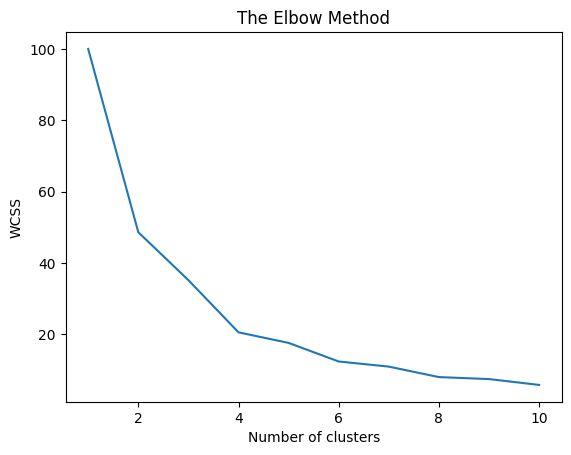

In [110]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [111]:
sil_scores = []
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k={k}  Silhouette Score: {score:.4f}")

optimal_k = sil_scores.index(max(sil_scores)) + 2
print(f"\nOptimal k based on silhouette: {optimal_k}")

k=2  Silhouette Score: 0.4364
k=3  Silhouette Score: 0.3818
k=4  Silhouette Score: 0.4434
k=5  Silhouette Score: 0.3816
k=6  Silhouette Score: 0.4059
k=7  Silhouette Score: 0.4011

Optimal k based on silhouette: 4


In [112]:

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

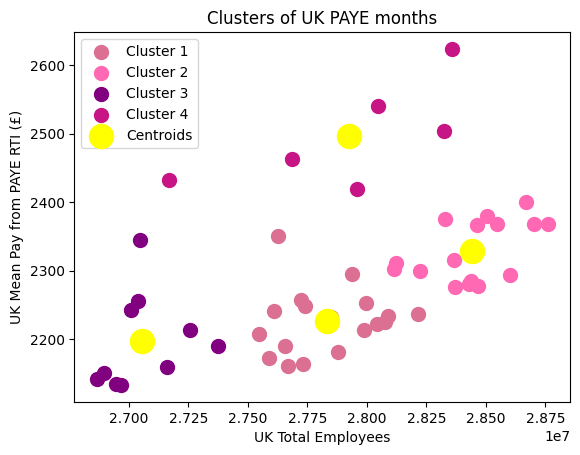

In [113]:
centroids_orig = sc.inverse_transform(kmeans.cluster_centers_)

colors = ['palevioletred', 'hotpink', 'purple', 'mediumvioletred', 'magenta']

for i in range(optimal_k):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=100, c=colors[i], label=f'Cluster {i + 1}')

plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            s=300, c='yellow', label='Centroids')

plt.title('Clusters of UK PAYE months')
plt.xlabel('UK Total Employees')
plt.ylabel('UK Mean Pay from PAYE RTI (£)')
plt.legend()
plt.show()

In [114]:
cluster_data = dataset.copy()
cluster_data['Cluster'] = y_kmeans

print("Cluster assignment counts:")
print(cluster_data['Cluster'].value_counts().sort_index())

print("\nCluster summary (original scale):")
print(cluster_data.groupby('Cluster')[['Employees', 'PAYE']].describe())

Cluster assignment counts:
Cluster
0    18
1    16
2    10
3     6
Name: count, dtype: int64

Cluster summary (original scale):
        Employees                                                      \
            count        mean            std         min          25%   
Cluster                                                                 
0            18.0  27831311.0  203278.222277  27545083.0  27657713.25   
1            16.0  28443694.5  189799.630138  28114924.0  28355627.00   
2            10.0  27054925.4  162726.870354  26865396.0  26950329.50   
3             6.0  27923939.5  445442.337588  27168394.0  27754400.25   

                                              PAYE                          \
                50%          75%         max count         mean        std   
Cluster                                                                      
0        27796269.5  27994457.50  28213802.0  18.0  2226.722222  47.126620   
1        28450930.5  28558525.25  28760549.0  16